In [ ]:
!pip install -q ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 9.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
import itertools
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from ortools.sat.python import cp_model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# csv path
PANELS_PATH = "/content/drive/MyDrive/FYP/panels.csv"

# PBU test size (can increase later: 5 → 10 → 15 → 20 → 25)
N_TEST_PBUS = 25

# Process times in hours (casting and mould change)
CAST_TIME_H = 6.0
T_LEN_H     = 3.5   # length change
T_CEIL_H    = 3.5   # ceiling change
T_RECESS_H  = 3.0   # recess change
T_OPEN_H    = 2.0   # openings change

# Process times scaled to half hours for CP-SAT integer math
SCALE   = 2
CAST_T  = int(CAST_TIME_H * SCALE)   # 12
T_LEN   = int(T_LEN_H   * SCALE)     # 7
T_CEIL  = int(T_CEIL_H  * SCALE)     # 7
T_RECESS= int(T_RECESS_H* SCALE)     # 6
T_OPEN  = int(T_OPEN_H  * SCALE)     # 4

# Geometry constraints: min 300mm spacing between panels
SPACING_MM = 300

# Mould dictionary
MOULDS = [
    {"mould_id": "M1a", "mould_type": "square", "max_length": 3900},
    {"mould_id": "M1b", "mould_type": "square", "max_length": 3900},
    {"mould_id": "M1c", "mould_type": "square", "max_length": 3900},
    {"mould_id": "M1d", "mould_type": "square", "max_length": 3900},
    {"mould_id": "M2", "mould_type": "square", "max_length": 3000},
    {"mould_id": "M3", "mould_type": "cross",  "max_length": 2000, "quadrant_limit": 2000},
]
moulds_df = pd.DataFrame(MOULDS)

print("Moulds:")
display(moulds_df)

Moulds:


,mould_id,mould_type,max_length,quadrant_limit
0,M1a,square,3900,NaN
1,M1b,square,3900,NaN
2,M1c,square,3900,NaN
3,M1d,square,3900,NaN
4,M2,square,3000,NaN
5,M3,cross,2000,2000.0


In [ ]:
panels_raw = pd.read_csv(PANELS_PATH)

# to validate columns in the csv
required = ["panel_id", "a_len", "b_len", "has_recess", "has_ceiling", "num_openings"]
missing = [c for c in required if c not in panels_raw.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

panels = panels_raw.copy()
panels["pbu_id"]     = panels["panel_id"].str.split("/").str[0]
panels["panel_code"] = panels["panel_id"].str.split("/").str[1]
panels["a_len"]        = panels["a_len"].astype(int)
panels["b_len"]        = panels["b_len"].astype(int)
panels["has_recess"]   = panels["has_recess"].astype(int)
panels["has_ceiling"]  = panels["has_ceiling"].astype(int)
panels["num_openings"] = panels["num_openings"].astype(int)

# for selecting the test PBUs
pbu_ids   = sorted(panels["pbu_id"].unique())
test_pbus = pbu_ids[:N_TEST_PBUS]
panels_test = panels[panels["pbu_id"].isin(test_pbus)].copy().reset_index(drop=True)

print(f"Total panels in CSV : {len(panels)}")
print(f"PBUs selected       : {len(test_pbus)}")
print(f"Panels in test      : {len(panels_test)}")

# checking which panels can fit in the cross moulds and which requires the square moulds
cross_fit = (panels_test["a_len"] <= 2000) & (panels_test["b_len"] <= 2000)
print(f"Panels fitting cross: {cross_fit.sum()}")
print(f"Panels needing square: {(~cross_fit).sum()}")

display(panels_test[["panel_id","a_len","b_len","has_ceiling","has_recess","num_openings"]])

Total panels in CSV : 75
PBUs selected       : 25
Panels in test      : 75
Panels fitting cross: 50
Panels needing square: 25


,panel_id,a_len,b_len,has_ceiling,has_recess,num_openings
0,1a/C02,1940,2875,1,0,2
1,1a/C03,625,1890,0,1,0
2,1a/C04,1010,1315,0,1,1
3,1b/C02,1940,2875,1,0,1
4,1b/C03,625,1890,0,1,1
...,...,...,...,...,...,...
70,5a/C03,1640,1740,1,1,1
71,5a/C04,625,960,0,1,1
72,5a(a)/C02,1440,2550,1,1,1
73,5a(a)/C03,1640,1740,1,1,1


In [ ]:
# defining functions related to placing panels within the moulds

# corners of square moulds, quadrants of cross moulds
CORNERS        = ["NW", "NE", "SW", "SE"]
DIAGONAL_PAIRS = [("NW", "SE"), ("NE", "SW")]
QUADRANTS      = ["Q1", "Q2", "Q3", "Q4"]

# corner-to-(horizontal,vertical) lookup tables
# "ba" ->> h=b_len, v=a_len
# "ab" ->> h=a_len, v=b_len

CORNER_MAP_V1 = {
    "C02": {"SW": "ba", "SE": "ab", "NW": "ba", "NE": "ab"},
    "C03": {"SW": "ba", "SE": "ab", "NW": "ab", "NE": "ba"},
    "C04": {"SW": "ab", "SE": "ba", "NW": "ba", "NE": "ab"},
}

# V2 ->> mirrored orientation of V1 (swap left to right)
CORNER_MAP_V2 = {}
for _code, _mapping in CORNER_MAP_V1.items():
    CORNER_MAP_V2[_code] = {
        "SW": _mapping["SE"],
        "SE": _mapping["SW"],
        "NW": _mapping["NE"],
        "NE": _mapping["NW"],
    }

# mapping of quadrant to corner for cross mould
QUADRANT_TO_CORNER = {
    "Q1": "NW",
    "Q2": "NE",
    "Q3": "SW",
    "Q4": "SE",
}

# PBU types that follow V2 orientation
# all other types default to V1
V2_PBU_TYPES = {
    "1a", "1b", "1c", "1d", "1e",
    "2b-m",
    "3a-m", "3a-m(a)",
    "3b-m", "3b-m(a)",
    "4b-m", "4b-m(a)",
    "5a", "5a(a)",
}

# to determine is panel belongs to V1 or V2 based on pbu type
def get_pbu_version(panel):
    pbu_type = str(panel.get("pbu_type", "")).strip().lower()
    # check against V2 set
    for v2_type in V2_PBU_TYPES:
        if pbu_type == v2_type.lower():
            return "V2"
    return "V1"


# return single valid (h,v) in mm for a panel at a given mould corner
def get_hv_for_corner(panel, corner):
    a = int(panel["a_len"])
    b = int(panel["b_len"])
    code = panel.get("panel_code", "")

    version = get_pbu_version(panel)

    if version == "V2":
        mapping = CORNER_MAP_V2.get(code)
    else:
        mapping = CORNER_MAP_V1.get(code)

    if mapping is None:
        # if unknown panel code go back to (a, b)
        return (a, b)

    hv_rule = mapping[corner]
    if hv_rule == "ba":
        return (b, a)
    else:
        return (a, b)

def get_hv_for_quadrant(panel, quadrant):
    equivalent_corner = QUADRANT_TO_CORNER[quadrant]
    return get_hv_for_corner(panel, equivalent_corner)


In [ ]:
# placing panels within square mould
def find_placement_square(combo, mould):
    n = len(combo)
    if n == 0 or n > 4:
        return None
    L = int(mould["max_length"])
    for p in combo:
        if max(int(p["a_len"]), int(p["b_len"])) > L:
            return None

    for chosen in itertools.combinations(CORNERS, n): # n unique corners from CORNERS list
        for perm in itertools.permutations(combo): # testing panel-to-corner mapping for n panels to chosen n corners
            placed = dict(zip(chosen, perm)) # creates dictionary of chosen corner to assigned panels

            # Get fixed (h, v) per panel-corner pair
            hv = {}
            for c in chosen:
                hv[c] = get_hv_for_corner(placed[c], c)

            # ── Diagonal ceiling constraint ──
            diag_ok = True
            for c1, c2 in DIAGONAL_PAIRS:
                if c1 in placed and c2 in placed:
                    if int(placed[c1]["has_ceiling"]) and int(placed[c2]["has_ceiling"]):
                        diag_ok = False
                        break
            if not diag_ok:
                continue

            # panel adjacency spacing checks
            ok = True
            if ok and "NW" in hv and "NE" in hv:
                if hv["NW"][0] + hv["NE"][0] + SPACING_MM > L:
                    ok = False
            if ok and "SW" in hv and "SE" in hv:
                if hv["SW"][0] + hv["SE"][0] + SPACING_MM > L:
                    ok = False
            if ok and "NW" in hv and "SW" in hv:
                if hv["NW"][1] + hv["SW"][1] + SPACING_MM > L:
                    ok = False
            if ok and "NE" in hv and "SE" in hv:
                if hv["NE"][1] + hv["SE"][1] + SPACING_MM > L:
                    ok = False

            if ok:
                result = {}
                for c in chosen:
                    p = placed[c]
                    horiz_leg, vert_leg = hv[c]
                    result[c] = {
                        "panel": p, "horiz": horiz_leg, "vert": vert_leg,
                        "a_len": int(p["a_len"]), "b_len": int(p["b_len"]),
                    }
                return result
    return None

# cross mould placement
# each panel has exactly one valid (horizontal,vertical) or (h,v) at each quadrant
def find_placement_cross(combo, mould):
    n = len(combo)
    if n == 0 or n > 4:
        return None

    q = int(mould["quadrant_limit"])

    # quick reject: any panel too large in either dimension?
    for p in combo:
        if int(p["a_len"]) > q or int(p["b_len"]) > q:
            return None

    for chosen in itertools.combinations(QUADRANTS, n):
        for perm in itertools.permutations(combo):
            assigned = dict(zip(chosen, perm))

            ok = True
            placements = {}

            for qname in chosen:
                p = assigned[qname]
                h, v = get_hv_for_quadrant(p, qname)

                if h > q or v > q:
                    ok = False
                    break

                placements[qname] = {
                    "panel": p,
                    "horiz": h,
                    "vert": v,
                    "a_len": int(p["a_len"]),
                    "b_len": int(p["b_len"]),
                }

            if ok:
                return placements

    return None


def find_placement(combo, mould): # placement function to match the type of mould
    if mould["mould_type"] == "square":
        return find_placement_square(combo, mould)
    if mould["mould_type"] == "cross":
        return find_placement_cross(combo, mould)
    return None

# check overall feasibility
def is_feasible(combo, mould):
    return find_placement(combo, mould) is not None

In [ ]:
# creating a 'recipe' for a manufacturing cycle
# recipe is the summary of the chosen characteristics of panels in the cycle
# returns a tuple consisting of 4 values
def recipe_for_cycle(panels_in_cycle):
    return (
        max(int(p["b_len"])        for p in panels_in_cycle),
        max(int(p["has_ceiling"])   for p in panels_in_cycle),
        max(int(p["has_recess"])    for p in panels_in_cycle),
        max(int(p["num_openings"])  for p in panels_in_cycle),
    )
    # by taking max for each characteristic
    # mould is configured to accommodate most demanding feature within that cycle
    # if 1 panel needs opening but other don't, mould will still be set up for an opening


# calculating time required to change mould setup
# from one recipe to the next
def setup_time_scaled(prev_recipe, new_recipe):
    """Returns setup time in SCALED units (half-hours)."""
    if prev_recipe is None: # first cycle on mould so no setup change needed
        return 0
    # if feature has changed, setup time is added to the total
    t = 0
    if prev_recipe[0] != new_recipe[0]: t += T_LEN # length change
    if prev_recipe[1] != new_recipe[1]: t += T_CEIL # ceiling change
    if prev_recipe[2] != new_recipe[2]: t += T_RECESS # recess change
    if prev_recipe[3] != new_recipe[3]: t += T_OPEN # opening change
    return t

In [ ]:
def panel_fits_cross(panel, qlimit):
    return int(panel["a_len"]) <= qlimit and int(panel["b_len"]) <= qlimit

# important function below
# to group panels into casting cycles then assign them to moulds
# aimed at balancing workload across all available moulds
# and minimise overall makespan

def build_cycles_balanced(panels_records, moulds_records):
    """
    Balanced strategy aiming to minimise makespan (max cycles on any mould):
      1. Separate big panels (square-only) from small panels (fit anywhere)
      2. Batch big panels into square cycles via round-robin
      3. Fill those cycles with small panels where possible
      4. Distribute remaining small panels across ALL moulds (including cross)
         using a least-loaded strategy
      5. Consolidate underfilled cycles
      6. Rebalance by moving cycles from overloaded to underloaded moulds
    """
    cross_moulds = [m for m in moulds_records if m["mould_type"] == "cross"]
    square_moulds = sorted(
        [m for m in moulds_records if m["mould_type"] == "square"],
        key=lambda m: int(m["max_length"]), reverse=True
    )

    has_cross = len(cross_moulds) > 0 # checks for available cross moulds
    cross = cross_moulds[0] if has_cross else None
    qlimit = int(cross["quadrant_limit"]) if cross else 0 # gets the quadrant limit of available mould

    # BIG PANELS: panels that cannot fit into a cross mould
    # SMALL PANELS: panels that can fit into a square mould
    if has_cross:
        big_panels = [p for p in panels_records if not panel_fits_cross(p, qlimit)]
        small_panels = [p for p in panels_records if panel_fits_cross(p, qlimit)]
    else:
        big_panels = list(panels_records)
        small_panels = []

    # panels are then sorted
    big_panels.sort(key=lambda p: (int(p["b_len"]), int(p["has_ceiling"])), reverse=True) # by b_len and has_ceiling descending
    small_panels.sort(key=lambda p: int(p["b_len"]), reverse=True) # by b_len descenfing

    all_mould_ids_local = [m["mould_id"] for m in moulds_records]
    moulds_by_id = {m["mould_id"]: m for m in moulds_records} # dictionary for lookup of mould info by their id

    cycles = [] # empty list to store generated casting cycles
    open_cycle_ids = []  # list to keep track of indices of cycles that still have space (<4 panels)
    cid = 0

    # to count how many cycles assigned to each mould
    def get_cycle_counts():
        counts = {mid: 0 for mid in all_mould_ids_local}
        for c in cycles:
            counts[c["mould_id"]] += 1
        return counts

    # to return the mould with the fewest cycles assigned to it
    def least_loaded_mould(mould_list):
        counts = get_cycle_counts()
        return min(mould_list, key=lambda m: counts[m["mould_id"]])

    # to get indices of open cycles for specific mould
    # sorted based on how full they are
    def open_cycles_for_mould(mid):
        return sorted(
            [idx for idx in open_cycle_ids if cycles[idx]["mould_id"] == mid],
            key=lambda i: len(cycles[i]["panels"])
        )

    # 1. Place big panels on square moulds (round-robin method)
    sq_ptr = 0 # scheduling pointer
    for panel in big_panels:
        placed = False

        # try placing in existing square mould cycles first
        for idx in sorted(open_cycle_ids,
                          key=lambda i: len(cycles[i]["panels"]), reverse=True):
            cyc = cycles[idx]
            if moulds_by_id[cyc["mould_id"]]["mould_type"] != "square":
                continue
            m = moulds_by_id[cyc["mould_id"]]
            test = cyc["panels"] + [panel]
            if len(test) <= 4 and is_feasible(test, m): # to check if panel fits with others in the cycle
                cyc["panels"].append(panel)
                cyc["recipe"] = recipe_for_cycle(cyc["panels"])
                if len(cyc["panels"]) == 4:
                    open_cycle_ids.remove(idx)
                placed = True
                break

        # if can't fit in existing open mould cycle
        # create new cycle on least-loaded square mould
        if not placed:
            for attempt in range(len(square_moulds)):
                m = square_moulds[(sq_ptr + attempt) % len(square_moulds)]
                if is_feasible([panel], m):
                    new_cyc = {
                        "cycle_id": cid,
                        "mould_id": m["mould_id"],
                        "panels": [panel],
                        "recipe": recipe_for_cycle([panel]),
                    }
                    cycles.append(new_cyc)
                    open_cycle_ids.append(cid)
                    cid += 1
                    sq_ptr = (sq_ptr + attempt + 1) % len(square_moulds) # try round-robin for an even initial spread
                    placed = True
                    break

    # 2. Fill open square mould cycles with small panels
    remaining_small = []
    for panel in small_panels:
        placed = False
        # try placing in existing square mould cycles that are not yet full
        # prioritising the fullest ones to complete them
        for idx in sorted(open_cycle_ids,
                          key=lambda i: len(cycles[i]["panels"]), reverse=True):
            cyc = cycles[idx]
            m = moulds_by_id[cyc["mould_id"]]
            test = cyc["panels"] + [panel]
            if len(test) <= 4 and is_feasible(test, m):
                cyc["panels"].append(panel)
                cyc["recipe"] = recipe_for_cycle(cyc["panels"])
                if len(cyc["panels"]) == 4:
                    open_cycle_ids.remove(idx)
                placed = True
                break
        if not placed: # panels that cannot be placed in this step
            remaining_small.append(panel) # moved to the remaining panels

    # 3. Distribute remaining small panels across ALL moulds

    # to note: can use least-loaded mould strategy to balance the cycle counts
    # by batching small panels into groups of up to 4 then assign to least-loaded mould

    # remaining panels sorted again to help with batching
    remaining_small.sort(key=lambda p: (
        int(p["b_len"]), int(p["has_ceiling"]),
        int(p["has_recess"]), int(p["num_openings"])
    ))

    still_remaining = []
    for panel in remaining_small:
        placed = False

        # try to add to ANY existing open cycle
        # prioritising least-loaded mould then fullest cycles on those moulds
        candidates = sorted(
            open_cycle_ids,
            key=lambda i: (
                get_cycle_counts()[cycles[i]["mould_id"]],  # to get least-loaded mould
                -len(cycles[i]["panels"])  # to get fullest cycle
            )
        )
        for idx in candidates:
            cyc = cycles[idx]
            m = moulds_by_id[cyc["mould_id"]]
            test = cyc["panels"] + [panel]
            if len(test) <= 4 and is_feasible(test, m):
                cyc["panels"].append(panel)
                cyc["recipe"] = recipe_for_cycle(cyc["panels"])
                if len(cyc["panels"]) == 4:
                    open_cycle_ids.remove(idx)
                placed = True
                break

        # if panel doesn't fit into any existing open mould cycle
        # new cycle is again createdd
        # this cycle is opened on least-loaded mould that can take it
        if not placed:
            counts = get_cycle_counts()
            sorted_moulds = sorted(moulds_records,
                                   key=lambda m: counts[m["mould_id"]])
            for m in sorted_moulds:
                if is_feasible([panel], m):
                    new_cyc = {
                        "cycle_id": cid,
                        "mould_id": m["mould_id"],
                        "panels": [panel],
                        "recipe": recipe_for_cycle([panel]),
                    }
                    cycles.append(new_cyc)
                    open_cycle_ids.append(cid)
                    cid += 1
                    placed = True
                    break

        if not placed:
            still_remaining.append(panel)

    # if any panels are still unplaced (normally is not like this)
    # warning is printed
    if still_remaining:
        print(f"WARNING: {len(still_remaining)} panels could not be placed!")
        # if can panels are forced into cross mould
        if has_cross:
            for i in range(0, len(still_remaining), 4):
                batch = still_remaining[i:i + 4]
                cycles.append({
                    "cycle_id": cid,
                    "mould_id": cross["mould_id"],
                    "panels": batch,
                    "recipe": recipe_for_cycle(batch),
                })
                cid += 1

    # 4. Consolidate underfilled cycles on the same mould

    # attempts to bring tgt 2 cycles with <4 panels on the same mould
    # into one single cycle
    # provided that the combined panels fit and do not exceed the limit of 4 panels
    for mid in all_mould_ids_local:
        m = moulds_by_id[mid]
        changed_merge = True
        while changed_merge:
            changed_merge = False
            mid_cycles = [c for c in cycles if c["mould_id"] == mid]
            # to sort by panel count ascending so we merge the smallest first
            mid_cycles.sort(key=lambda c: len(c["panels"]))

            for i in range(len(mid_cycles)):
                for j in range(i + 1, len(mid_cycles)):
                    combined = mid_cycles[i]["panels"] + mid_cycles[j]["panels"]
                    if len(combined) <= 4 and is_feasible(combined, m):
                        # Merge j into i
                        mid_cycles[i]["panels"] = combined
                        mid_cycles[i]["recipe"] = recipe_for_cycle(combined)
                        # Remove j from cycles
                        to_remove = mid_cycles[j]
                        cycles.remove(to_remove)
                        if to_remove["cycle_id"] in [cycles[idx]["cycle_id"]
                                                      for idx in open_cycle_ids
                                                      if idx < len(cycles)]:
                            pass  # open_cycle_ids list will rebuild after this
                        changed_merge = True
                        break
                if changed_merge:
                    break

    # rebuilding open_cycle_ids list after consolidating
    open_cycle_ids = [i for i, c in enumerate(cycles) if len(c["panels"]) < 4]

    # 5. Rebalance across ALL moulds

    # evening out total no of cycles across all moulds
    # by moving cycles from overloaded moulds to underloaded moulds
    changed = True
    iterations = 0
    while changed and iterations < 200:
        changed = False
        iterations += 1

        counts = get_cycle_counts()
        max_mid = max(counts, key=counts.get) # most loaded mould
        min_mid = min(counts, key=counts.get) # least loaded mould

        if counts[max_mid] - counts[min_mid] < 2:
            break

        target_m = moulds_by_id[min_mid]

        # try to move a cycle from max_mid to min_mid
        # prioritise moving smaller cycles first since easier to fit
        max_cycles = sorted(
            [c for c in cycles if c["mould_id"] == max_mid],
            key=lambda c: len(c["panels"])
        )
        for c in max_cycles:
            if is_feasible(c["panels"], target_m):
                c["mould_id"] = min_mid
                changed = True
                break

    # 6. Final part — try to fill any remaining 1-panel cycles

    # looks for 1-panel cycles and try to steal panels from 4-panel cycles
    # on the same or other moulds to make it more even
    for c in cycles:
        if len(c["panels"]) >= 3:
            continue
        # for underfilled cycle try to take panels from full cycles on the same mould
        m = moulds_by_id[c["mould_id"]]
        same_mould_cycles = [
            other for other in cycles
            if other["mould_id"] == c["mould_id"]
            and other["cycle_id"] != c["cycle_id"]
            and len(other["panels"]) == 4
        ]
        for donor in same_mould_cycles: # donor is for cycle where panel is taken
            if len(c["panels"]) >= 3:
                break
            # try removing each panel from donor and adding to c
            for p_idx in range(len(donor["panels"]) - 1, -1, -1):
                panel = donor["panels"][p_idx]
                test_c = c["panels"] + [panel]
                test_d = donor["panels"][:p_idx] + donor["panels"][p_idx + 1:]
                if (len(test_c) <= 4
                    and is_feasible(test_c, m)
                    and is_feasible(test_d, m)):
                    c["panels"] = test_c
                    c["recipe"] = recipe_for_cycle(test_c)
                    donor["panels"] = test_d
                    donor["recipe"] = recipe_for_cycle(test_d)
                    break

    # cycle ids renumbered for neatness
    for i, c in enumerate(cycles):
        c["cycle_id"] = i

    return cycles

# run
moulds_records = moulds_df.to_dict("records")
panels_records = panels_test.to_dict("records")
cycles = build_cycles_balanced(panels_records, moulds_records)

print("Cycles per mould:")
print(pd.Series([c["mould_id"] for c in cycles]).value_counts().sort_index())
print(f"\nTotal panels assigned: {sum(len(c['panels']) for c in cycles)}")
print(f"Total panels in test: {len(panels_test)}")

Cycles per mould:
M1a    4
M1b    4
M1c    4
M1d    4
M2     4
M3     3
Name: count, dtype: int64

Total panels assigned: 75
Total panels in test: 75


In [ ]:
# taking cycles data and presenting in table format
def cycles_to_df(cycles):
    rows = []
    for c in cycles:
        rows.append({
            "cycle_id":  c["cycle_id"],
            "mould_id":  c["mould_id"],
            "n_panels":  len(c["panels"]),
            "panel_ids": [p["panel_id"] for p in c["panels"]],
            "recipe":    c["recipe"],
        })
    return pd.DataFrame(rows).sort_values(["mould_id", "cycle_id"]).reset_index(drop=True)

cycles_df = cycles_to_df(cycles)
display(cycles_df)

# detailed printout of each cycle
print("\n~~~~~~~~ CYCLE DETAILS (generation order) ~~~~~~~~")
for cyc in sorted(cycles, key=lambda c: (c["mould_id"], c["cycle_id"])):
    pids = [p["panel_id"] for p in cyc["panels"]]
    r = cyc["recipe"]
    print(f"\nCycle {cyc['cycle_id']} | {cyc['mould_id']} | {len(pids)} panels")
    print(f"  Panels : {pids}")
    print(f"  Recipe : b_len={r[0]}, ceil={r[1]}, recess={r[2]}, openings={r[3]}")

# summart of allocation
print("\n~~~~~~~~~~ SUMMARY ~~~~~~~~~~~")
print(f"Total cycles : {len(cycles)}")
print(f"Total panels : {sum(len(c['panels']) for c in cycles)}")
for mid in sorted(set(c["mould_id"] for c in cycles)):
    n = sum(1 for c in cycles if c["mould_id"] == mid)
    p = sum(len(c["panels"]) for c in cycles if c["mould_id"] == mid)
    print(f"  {mid}: {n} cycles, {p} panels")

print("\nNote: After CP-SAT sequencing (Cell 10), cycles will be")
print("reordered per mould. Step numbers shown in Cell 11.")

,cycle_id,mould_id,n_panels,panel_ids,recipe
0,0,M1a,3,"[1a/C02, 4a/C02, 1a/C03]","(2875, 1, 1, 2)"
1,5,M1a,4,"[1e/C02, 4b-m/C02, 1d/C03, 5a(a)/C04]","(2875, 1, 1, 1)"
2,10,M1a,4,"[3a-m(a)/C02, 3b/C02, 2b-m/C03, 4b(a)/C04]","(2625, 1, 1, 1)"
3,18,M1a,3,"[3b-m/C03, 3b-m(a)/C03, 4b-m/C04]","(1665, 1, 1, 1)"
4,1,M1b,3,"[1b/C02, 4a(a)/C02, 1b/C03]","(2875, 1, 1, 1)"
5,6,M1b,3,"[2a/C02, 4b-m(a)/C02, 1e/C03]","(2865, 1, 1, 1)"
6,11,M1b,3,"[3b(a)/C02, 3b-m/C02, 4b-m(a)/C04]","(2625, 1, 1, 1)"
7,19,M1b,2,"[5a/C03, 5a(a)/C03]","(1740, 1, 1, 1)"
8,2,M1c,3,"[1c/C02, 4b/C02, 1c/C03]","(2875, 1, 1, 1)"
9,7,M1c,4,"[2b/C02, 3a/C02, 2a/C03, 4a(a)/C04]","(2865, 1, 1, 1)"



~~~~~~~~ CYCLE DETAILS (generation order) ~~~~~~~~

Cycle 0 | M1a | 3 panels
  Panels : ['1a/C02', '4a/C02', '1a/C03']
  Recipe : b_len=2875, ceil=1, recess=1, openings=2

Cycle 5 | M1a | 4 panels
  Panels : ['1e/C02', '4b-m/C02', '1d/C03', '5a(a)/C04']
  Recipe : b_len=2875, ceil=1, recess=1, openings=1

Cycle 10 | M1a | 4 panels
  Panels : ['3a-m(a)/C02', '3b/C02', '2b-m/C03', '4b(a)/C04']
  Recipe : b_len=2625, ceil=1, recess=1, openings=1

Cycle 18 | M1a | 3 panels
  Panels : ['3b-m/C03', '3b-m(a)/C03', '4b-m/C04']
  Recipe : b_len=1665, ceil=1, recess=1, openings=1

Cycle 1 | M1b | 3 panels
  Panels : ['1b/C02', '4a(a)/C02', '1b/C03']
  Recipe : b_len=2875, ceil=1, recess=1, openings=1

Cycle 6 | M1b | 3 panels
  Panels : ['2a/C02', '4b-m(a)/C02', '1e/C03']
  Recipe : b_len=2865, ceil=1, recess=1, openings=1

Cycle 11 | M1b | 3 panels
  Panels : ['3b(a)/C02', '3b-m/C02', '4b-m(a)/C04']
  Recipe : b_len=2625, ceil=1, recess=1, openings=1

Cycle 19 | M1b | 2 panels
  Panels : ['5a/

In [ ]:
# recipe diversity analysis
print("=" * 60)
print("RECIPE DIVERSITY ANALYSIS")
print("=" * 60)

# Define all_mould_ids as it's used in this cell but defined later in the original notebook
all_mould_ids = moulds_df["mould_id"].tolist()

total_transitions = 0
b_changes = 0
c_changes = 0
r_changes = 0
o_changes = 0

for mid in all_mould_ids:
    bl_seq = [c for c in cycles if c["mould_id"] == mid]
    prev = None
    for cyc in bl_seq:
        if prev is not None:
            total_transitions += 1
            if prev[0] != cyc["recipe"][0]: b_changes += 1
            if prev[1] != cyc["recipe"][1]: c_changes += 1
            if prev[2] != cyc["recipe"][2]: r_changes += 1
            if prev[3] != cyc["recipe"][3]: o_changes += 1
        prev = cyc["recipe"]

print(f"\nTotal cycles: {len(cycles)}")
print(f"Total transitions: {total_transitions}")
print(f"\nAttribute change frequency (baseline):")
print(f"  b_len:         {b_changes}/{total_transitions}  ({b_changes * 3.5:.1f}h)")
print(f"  has_ceiling:   {c_changes}/{total_transitions}  ({c_changes * 3.5:.1f}h)")
print(f"  has_recess:    {r_changes}/{total_transitions}  ({r_changes * 3.0:.1f}h)")
print(f"  num_openings:  {o_changes}/{total_transitions}  ({o_changes * 2.0:.1f}h)")
print(f"  Total setup:   {b_changes*3.5 + c_changes*3.5 + r_changes*3.0 + o_changes*2.0:.1f}h")

# Unique recipes
all_recipes = [c["recipe"] for c in cycles]
unique = set(all_recipes)
print(f"\nUnique recipes: {len(unique)} out of {len(cycles)} cycles")
for r in sorted(unique):
    print(f"  {r}  — {all_recipes.count(r)} cycles")

# Which attributes are constant?
print(f"\nAttribute variability:")
for i, attr in enumerate(["b_len", "ceiling", "recess", "openings"]):
    vals = set(r[i] for r in all_recipes)
    print(f"  {attr}: {len(vals)} unique values {sorted(vals)}")

RECIPE DIVERSITY ANALYSIS

Total cycles: 23
Total transitions: 17

Attribute change frequency (baseline):
  b_len:         15/17  (52.5h)
  has_ceiling:   2/17  (7.0h)
  has_recess:    0/17  (0.0h)
  num_openings:  7/17  (14.0h)
  Total setup:   73.5h

Unique recipes: 13 out of 23 cycles
  (1115, 1, 1, 1)  — 2 cycles
  (1305, 0, 1, 2)  — 1 cycles
  (1665, 1, 1, 0)  — 1 cycles
  (1665, 1, 1, 1)  — 1 cycles
  (1740, 1, 1, 1)  — 1 cycles
  (1815, 1, 1, 1)  — 2 cycles
  (1815, 1, 1, 2)  — 1 cycles
  (2550, 1, 1, 2)  — 1 cycles
  (2625, 1, 1, 1)  — 3 cycles
  (2625, 1, 1, 2)  — 1 cycles
  (2865, 1, 1, 1)  — 3 cycles
  (2875, 1, 1, 1)  — 5 cycles
  (2875, 1, 1, 2)  — 1 cycles

Attribute variability:
  b_len: 9 unique values [1115, 1305, 1665, 1740, 1815, 2550, 2625, 2865, 2875]
  ceiling: 2 unique values [0, 1]
  recess: 1 unique values [1]
  openings: 3 unique values [0, 1, 2]


In [ ]:
# CP-SAT sequencing
def optimize_sequences_cpsat(cycles, mould_ids, cast_time_scaled=CAST_T):
    cycles_by_mould = defaultdict(list)
    for c in cycles:
        cycles_by_mould[c["mould_id"]].append(c)
    for mid in mould_ids:
        _ = cycles_by_mould[mid]

    model = cp_model.CpModel()
    mould_total_time = {}
    arcs_by_mould = {}

    for mid in mould_ids:
        mc = cycles_by_mould[mid]
        k = len(mc)

        if k == 0:
            mould_total_time[mid] = 0
            arcs_by_mould[mid] = []
            continue

        if k == 1:
            mould_total_time[mid] = cast_time_scaled
            arcs_by_mould[mid] = []
            continue

        arcs = []
        setup_cost = {}
        for i in range(k + 1):
            for j in range(k + 1):
                if i == j:
                    continue
                lit = model.NewBoolVar(f"arc_{mid}_{i}_{j}")
                arcs.append((i, j, lit))
                if i == 0 or j == 0:
                    setup_cost[(i, j)] = 0
                else:
                    setup_cost[(i, j)] = setup_time_scaled(
                        mc[i - 1]["recipe"], mc[j - 1]["recipe"]
                    )

        model.AddCircuit(arcs)

        setup_terms = []
        for (i, j, lit) in arcs:
            if i > 0 and j > 0 and setup_cost[(i, j)] > 0:
                setup_terms.append(setup_cost[(i, j)] * lit)

        total_setup = model.NewIntVar(0, 1_000_000, f"setup_{mid}")
        if setup_terms:
            model.Add(total_setup == sum(setup_terms))
        else:
            model.Add(total_setup == 0)

        total_time = model.NewIntVar(0, 1_000_000, f"time_{mid}")
        model.Add(total_time == k * cast_time_scaled + total_setup)

        mould_total_time[mid] = total_time
        arcs_by_mould[mid] = arcs

    makespan = model.NewIntVar(0, 1_000_000, "makespan")
    for mid in mould_ids:
        tt = mould_total_time[mid]
        if isinstance(tt, int):
            model.Add(makespan >= tt)
        else:
            model.Add(makespan >= tt)

    model.Minimize(makespan)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 60
    status = solver.Solve(model)

    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        raise RuntimeError(f"CP-SAT failed: {solver.StatusName(status)}")

    sequences = {}
    times = {}

    for mid in mould_ids:
        mc = cycles_by_mould[mid]
        k = len(mc)

        if k == 0:
            sequences[mid] = []
            times[mid] = 0
            continue

        if k == 1:
            sequences[mid] = list(mc)
            times[mid] = cast_time_scaled
            continue

        arcs = arcs_by_mould[mid]
        next_node = {}
        for (i, j, lit) in arcs:
            if solver.Value(lit) == 1:
                next_node[i] = j

        order = []
        cur = 0
        for _ in range(k):
            nxt = next_node.get(cur)
            if nxt is None or nxt == 0:
                break
            order.append(nxt - 1)
            cur = nxt

        sequences[mid] = [mc[i] for i in order]
        tt = mould_total_time[mid]
        times[mid] = solver.Value(tt) if not isinstance(tt, int) else tt

    return sequences, solver.Value(makespan), times


all_mould_ids = moulds_df["mould_id"].tolist()
sequences_by_mould, makespan_scaled, time_by_mould = optimize_sequences_cpsat(
    cycles, mould_ids=all_mould_ids
)

print("~" * 40)
print("CP-SAT SEQUENCING RESULTS")
print("~" * 40)
print(f"Makespan: {makespan_scaled / SCALE:.1f} hours\n")
for mid in all_mould_ids:
    t = time_by_mould[mid] / SCALE
    n = len(sequences_by_mould[mid])
    print(f"  {mid}: {t:.1f} hours ({n} cycles)")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
CP-SAT SEQUENCING RESULTS
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Makespan: 40.0 hours

  M1a: 36.5 hours (4 cycles)
  M1b: 34.5 hours (4 cycles)
  M1c: 38.5 hours (4 cycles)
  M1d: 36.5 hours (4 cycles)
  M2: 40.0 hours (4 cycles)
  M3: 23.5 hours (3 cycles)


In [ ]:
def build_timeline(sequences_by_mould, all_mould_ids):
    rows = []
    for mid in all_mould_ids:
        seq = sequences_by_mould.get(mid, [])
        t = 0
        prev_recipe = None
        for step, cyc in enumerate(seq, start=1):
            st = setup_time_scaled(prev_recipe, cyc["recipe"])
            start = t
            end = start + st + CAST_T
            rows.append({
                "mould_id":    mid,
                "step":        step,
                "cycle_id":    cyc["cycle_id"],
                "n_panels":    len(cyc["panels"]),
                "panel_ids":   [p["panel_id"] for p in cyc["panels"]],
                "recipe":      cyc["recipe"],
                "setup_h":     st / SCALE,
                "cast_h":      CAST_T / SCALE,
                "start_h":     start / SCALE,
                "end_h":       end / SCALE,
            })
            t = end
            prev_recipe = cyc["recipe"]
    return pd.DataFrame(rows)

schedule_df = build_timeline(sequences_by_mould, all_mould_ids)

print("========== OPTIMIZED SCHEDULE (by start time) ==========\n")
display(schedule_df.sort_values(["start_h", "mould_id"]).reset_index(drop=True))

print("\n========== CASTING SEQUENCE PER MOULD ==========")
for mid in all_mould_ids:
    mdf = schedule_df[schedule_df["mould_id"] == mid].sort_values("step")
    print(f"\n--- {mid} ---")
    if mdf.empty:
        print("  (idle)")
        continue
    for _, r in mdf.iterrows():
        print(f"  Step {r['step']} (C{r['cycle_id']}) | "
              f"start={r['start_h']:5.1f}h | "
              f"setup={r['setup_h']:4.1f}h | "
              f"cast={r['cast_h']:.1f}h | "
              f"end={r['end_h']:5.1f}h")
        print(f"       panels: {r['panel_ids']}")

========== OPTIMIZED SCHEDULE (by start time) ==========



,mould_id,step,cycle_id,n_panels,panel_ids,recipe,setup_h,cast_h,start_h,end_h
0,M1a,1,5,4,"[1e/C02, 4b-m/C02, 1d/C03, 5a(a)/C04]","(2875, 1, 1, 1)",0.0,6.0,0.0,6.0
1,M1b,1,11,3,"[3b(a)/C02, 3b-m/C02, 4b-m(a)/C04]","(2625, 1, 1, 1)",0.0,6.0,0.0,6.0
2,M1c,1,7,4,"[2b/C02, 3a/C02, 2a/C03, 4a(a)/C04]","(2865, 1, 1, 1)",0.0,6.0,0.0,6.0
3,M1d,1,13,4,"[5a(a)/C02, 4a/C03, 1c-m/C04, 1d/C04]","(2550, 1, 1, 2)",0.0,6.0,0.0,6.0
4,M2,1,9,3,"[3a-m/C02, 3a(a)/C03, 1b/C04]","(2625, 1, 1, 1)",0.0,6.0,0.0,6.0
5,M3,1,15,4,"[3b/C04, 3b(a)/C04, 3b-m/C04, 3b-m(a)/C04]","(1115, 1, 1, 1)",0.0,6.0,0.0,6.0
6,M1a,2,10,4,"[3a-m(a)/C02, 3b/C02, 2b-m/C03, 4b(a)/C04]","(2625, 1, 1, 1)",3.5,6.0,6.0,15.5
7,M1b,2,6,3,"[2a/C02, 4b-m(a)/C02, 1e/C03]","(2865, 1, 1, 1)",3.5,6.0,6.0,15.5
8,M1c,2,20,3,"[4a(a)/C03, 4b/C03, 5a/C04]","(1815, 1, 1, 1)",3.5,6.0,6.0,15.5
9,M1d,2,21,3,"[4b(a)/C03, 4b-m/C03, 4a/C04]","(1815, 1, 1, 1)",5.5,6.0,6.0,17.5



========== CASTING SEQUENCE PER MOULD ==========

--- M1a ---
  Step 1 (C5) | start=  0.0h | setup= 0.0h | cast=6.0h | end=  6.0h
       panels: ['1e/C02', '4b-m/C02', '1d/C03', '5a(a)/C04']
  Step 2 (C10) | start=  6.0h | setup= 3.5h | cast=6.0h | end= 15.5h
       panels: ['3a-m(a)/C02', '3b/C02', '2b-m/C03', '4b(a)/C04']
  Step 3 (C18) | start= 15.5h | setup= 3.5h | cast=6.0h | end= 25.0h
       panels: ['3b-m/C03', '3b-m(a)/C03', '4b-m/C04']
  Step 4 (C0) | start= 25.0h | setup= 5.5h | cast=6.0h | end= 36.5h
       panels: ['1a/C02', '4a/C02', '1a/C03']

--- M1b ---
  Step 1 (C11) | start=  0.0h | setup= 0.0h | cast=6.0h | end=  6.0h
       panels: ['3b(a)/C02', '3b-m/C02', '4b-m(a)/C04']
  Step 2 (C6) | start=  6.0h | setup= 3.5h | cast=6.0h | end= 15.5h
       panels: ['2a/C02', '4b-m(a)/C02', '1e/C03']
  Step 3 (C19) | start= 15.5h | setup= 3.5h | cast=6.0h | end= 25.0h
       panels: ['5a/C03', '5a(a)/C03']
  Step 4 (C1) | start= 25.0h | setup= 3.5h | cast=6.0h | end= 34.5h
  

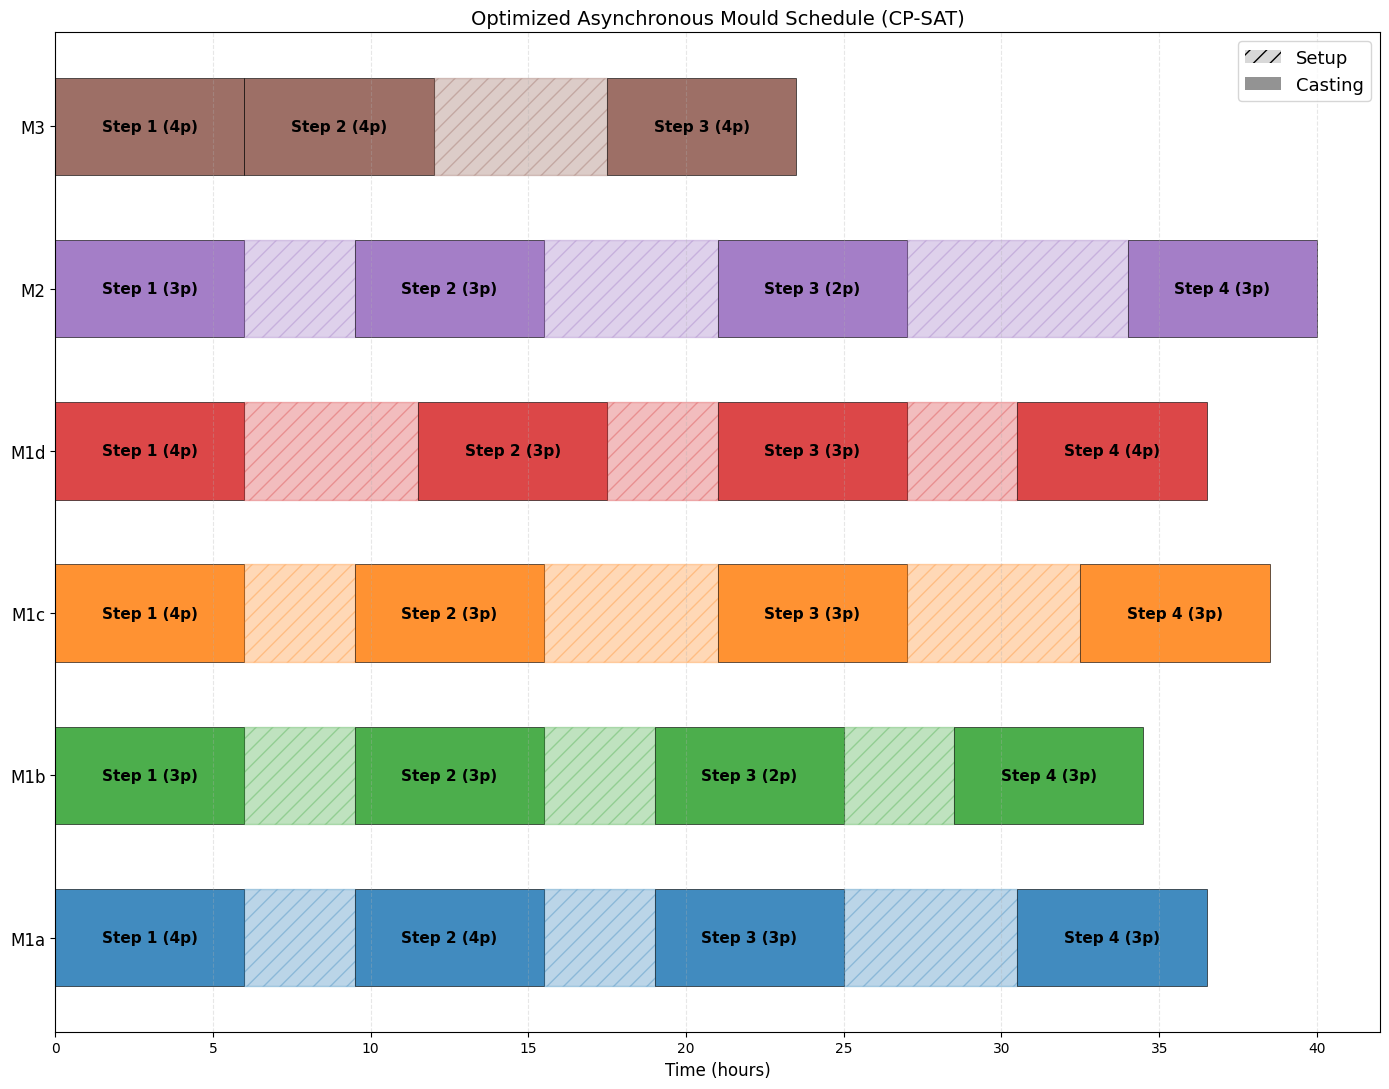

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def plot_gantt(schedule_df, all_mould_ids):
    colors = {
    "M1a": "#1f77b4", "M1b": "#2ca02c", "M1c": "#ff7f0e",
    "M1d": "#d62728", "M2": "#9467bd", "M3": "#8c564b"
}
    mould_to_y = {m: i for i, m in enumerate(all_mould_ids)}

    fig, ax = plt.subplots(figsize=(14, 2 + 1.5 * len(all_mould_ids)))

    for mid in all_mould_ids:
        mdf = schedule_df[schedule_df["mould_id"] == mid]
        y = mould_to_y[mid]
        if mdf.empty:
            ax.text(0.5, y, "(idle)", va="center", fontsize=10, color="gray")
            continue
        for _, r in mdf.iterrows():
            color = colors.get(mid, "tab:gray")
            if r["setup_h"] > 0:
                ax.barh(y, r["setup_h"], left=r["start_h"], height=0.6,
                        color=color, alpha=0.3, hatch="//", edgecolor=color)
            cast_start = r["start_h"] + r["setup_h"]
            ax.barh(y, r["cast_h"], left=cast_start, height=0.6,
                    color=color, alpha=0.85, edgecolor="black", linewidth=0.5)
            label = f"Step {int(r['step'])} ({r['n_panels']}p)"
            ax.text(cast_start + r["cast_h"] / 2, y, label,
                    ha="center", va="center", fontsize=11, fontweight="bold")

    ax.set_yticks(range(len(all_mould_ids)))
    ax.set_yticklabels(all_mould_ids, fontsize=12)
    ax.set_xlabel("Time (hours)", fontsize=12)
    ax.set_title("Optimized Asynchronous Mould Schedule (CP-SAT)", fontsize=14)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    legend_elements = [
        mpatches.Patch(facecolor="gray", alpha=0.3, hatch="//", label="Setup"),
        mpatches.Patch(facecolor="gray", alpha=0.85, label="Casting"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=13)
    plt.tight_layout()
    plt.savefig('sched.png')
    plt.show()

plot_gantt(schedule_df, all_mould_ids)
from google.colab import files
files.download('sched.png')

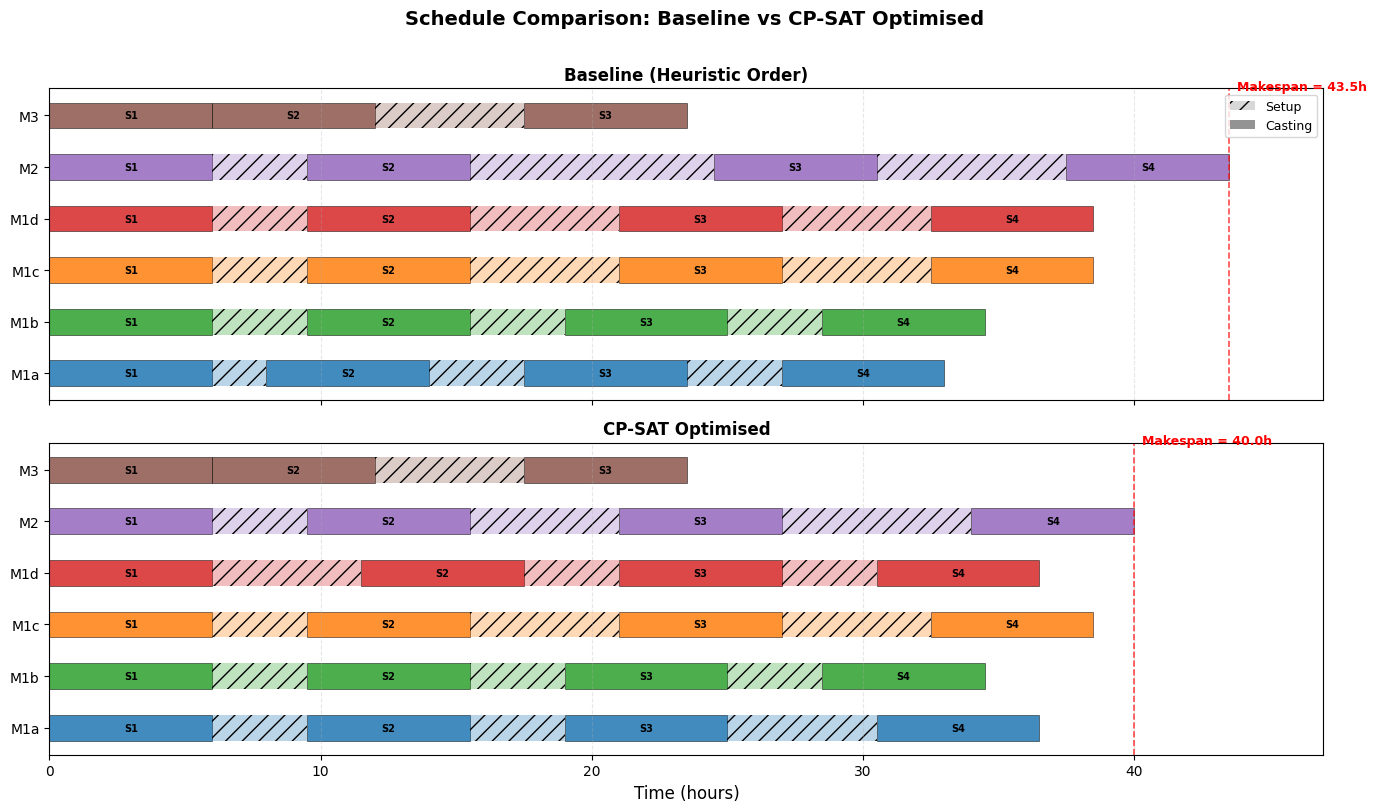

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# comparison Gantt for baseline vs optimized

def plot_comparison_gantt_simple(cycles, sequences_by_mould, all_mould_ids):
    """Two Gantt charts stacked: baseline on top, optimised below."""
    colors = {
        "M1a": "#1f77b4", "M1b": "#2ca02c", "M1c": "#ff7f0e",
        "M1d": "#d62728", "M2": "#9467bd", "M3": "#8c564b"
    }

    # build baseline timeline (heuristic order)
    bl_seq = defaultdict(list)
    for c in cycles:
        bl_seq[c["mould_id"]].append(c)
    bl_schedule = build_timeline(bl_seq, all_mould_ids)

    # optimised timeline
    opt_schedule = build_timeline(sequences_by_mould, all_mould_ids)

    schedules = [
        ("Baseline (Heuristic Order)", bl_schedule),
        ("CP-SAT Optimised", opt_schedule),
    ]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    global_max = max(bl_schedule["end_h"].max(), opt_schedule["end_h"].max()) * 1.08

    for ax_idx, (title, sched) in enumerate(schedules):
        ax = axes[ax_idx]
        for mid in all_mould_ids:
            mdf = sched[sched["mould_id"] == mid]
            y = all_mould_ids.index(mid)
            if mdf.empty:
                ax.text(0.5, y, "(idle)", va="center", fontsize=8, color="gray")
                continue
            for _, r in mdf.iterrows():
                color = colors.get(mid, "tab:gray")
                if r["setup_h"] > 0:
                    ax.barh(y, r["setup_h"], left=r["start_h"], height=0.5,
                            color=color, alpha=0.3, hatch="//")
                cs = r["start_h"] + r["setup_h"]
                ax.barh(y, r["cast_h"], left=cs, height=0.5,
                        color=color, alpha=0.85, edgecolor="black", linewidth=0.4)
                ax.text(cs + r["cast_h"] / 2, y, f"S{int(r['step'])}",
                        ha="center", va="center", fontsize=7, fontweight="bold")

        makespan = sched["end_h"].max()
        ax.axvline(makespan, color="red", linestyle="--", linewidth=1.2, alpha=0.7)
        ax.text(makespan + 0.3, len(all_mould_ids) - 0.5,
                f"Makespan = {makespan:.1f}h",
                fontsize=9, color="red", fontweight="bold")

        ax.set_xlim(0, global_max)
        ax.set_yticks(range(len(all_mould_ids)))
        ax.set_yticklabels(all_mould_ids, fontsize=10)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.grid(axis="x", linestyle="--", alpha=0.3)

    axes[-1].set_xlabel("Time (hours)", fontsize=12)
    legend_elements = [
        mpatches.Patch(facecolor="gray", alpha=0.3, hatch="//", label="Setup"),
        mpatches.Patch(facecolor="gray", alpha=0.85, label="Casting"),
    ]
    axes[0].legend(handles=legend_elements, loc="upper right", fontsize=9)
    plt.suptitle("Schedule Comparison: Baseline vs CP-SAT Optimised",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig('image.png')
    plt.show()

plot_comparison_gantt_simple(cycles, sequences_by_mould, all_mould_ids)
from google.colab import files
files.download('image.png')


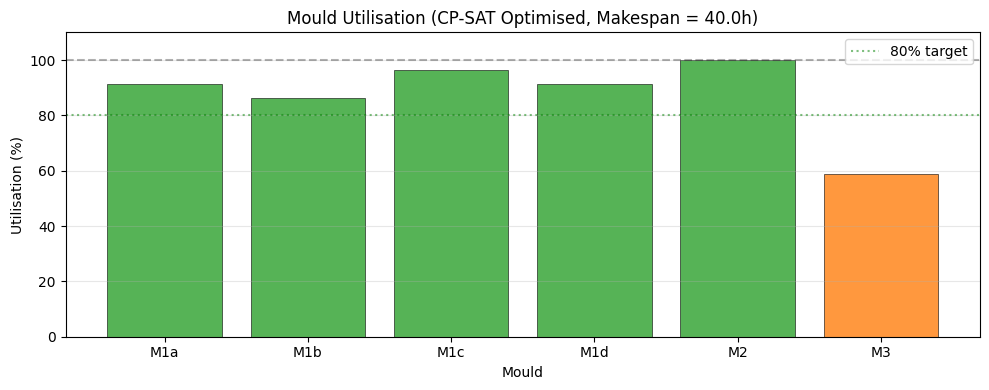

In [ ]:
# mould utilization chart

def plot_utilisation(sequences_by_mould, time_by_mould, all_mould_ids, makespan_scaled):
    """Bar chart of mould utilisation as % of makespan."""
    makespan_h = makespan_scaled / SCALE

    mids = []
    utils = []
    for mid in all_mould_ids:
        t = time_by_mould.get(mid, 0) / SCALE
        util = (t / makespan_h * 100) if makespan_h > 0 else 0
        mids.append(mid)
        utils.append(util)

    bar_colors = ["tab:green" if u >= 80 else "tab:orange" if u >= 50
                  else "tab:red" for u in utils]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(mids, utils, color=bar_colors, alpha=0.8, edgecolor="black", linewidth=0.5)
    ax.axhline(100, color="black", linestyle="--", alpha=0.3)
    ax.axhline(80, color="green", linestyle=":", alpha=0.5, label="80% target")
    ax.set_xlabel("Mould")
    ax.set_ylabel("Utilisation (%)")
    ax.set_title(f"Mould Utilisation (CP-SAT Optimised, Makespan = {makespan_h:.1f}h)")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 110)
    plt.tight_layout()
    plt.show()

plot_utilisation(sequences_by_mould, time_by_mould, all_mould_ids, makespan_scaled)

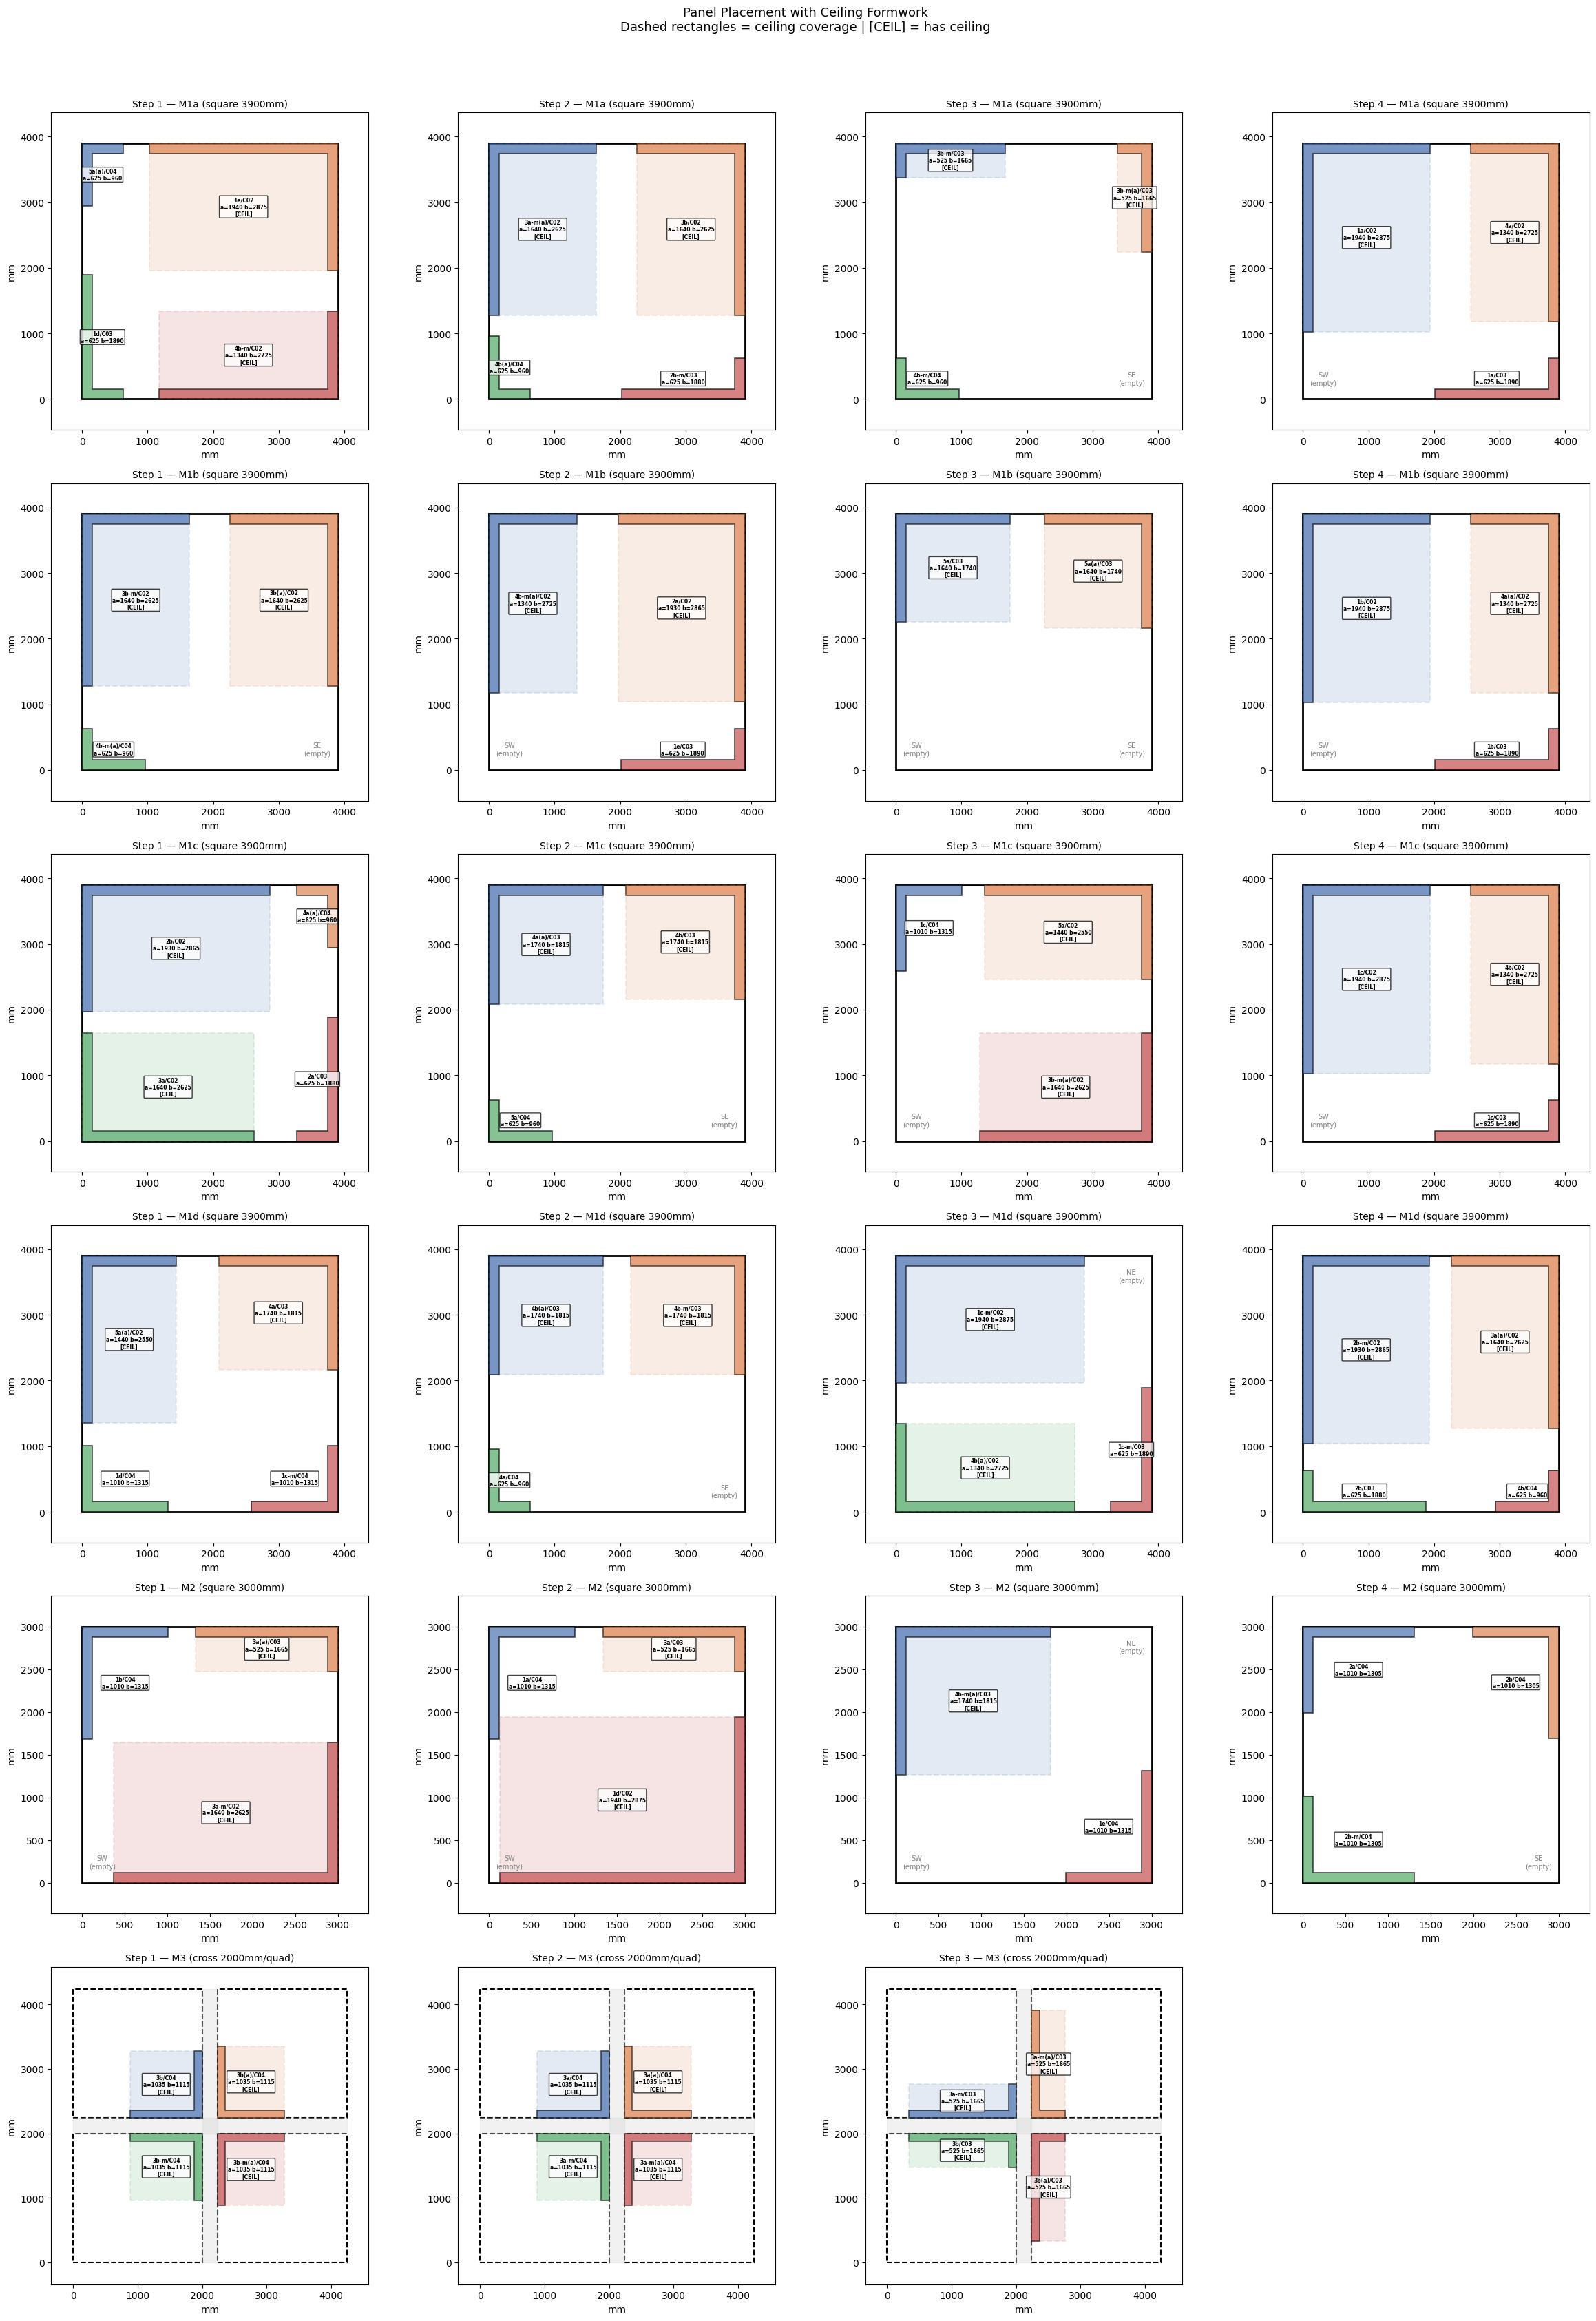

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# to visualize placements
def visualise_all_placements_with_ceiling(sequences_by_mould, moulds_df, all_mould_ids):
    moulds_dict = {m["mould_id"]: m for m in moulds_df.to_dict("records")}

    all_items = []
    for mid in all_mould_ids:
        seq = sequences_by_mould.get(mid, [])
        for step, cyc in enumerate(seq, start=1):
            all_items.append((mid, step, cyc))

    if not all_items:
        print("No cycles to visualise.")
        return

    ncols = min(len(all_items), 4)
    nrows = (len(all_items) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5.5 * nrows))
    if len(all_items) == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    corner_colors = {"NW": "#4C72B0", "NE": "#DD8452", "SW": "#55A868", "SE": "#C44E52"}
    quad_colors = {"Q1": "#4C72B0", "Q2": "#DD8452", "Q3": "#55A868", "Q4": "#C44E52"}

    corner_cfg = {
        "NW": {"origin": (0, 1), "h_dir": +1, "v_dir": -1},
        "NE": {"origin": (1, 1), "h_dir": -1, "v_dir": -1},
        "SW": {"origin": (0, 0), "h_dir": +1, "v_dir": +1},
        "SE": {"origin": (1, 0), "h_dir": -1, "v_dir": +1},
    }

    for idx, (mid, step, cyc) in enumerate(all_items):
        ax = axes[idx]
        mould = moulds_dict[mid]
        placement = find_placement(cyc["panels"], mould)

        if placement is None:
            ax.text(0.5, 0.5, f"Step {step}\n{mid}\nNo valid placement",
                    ha="center", va="center", transform=ax.transAxes, fontsize=10)
            ax.set_title(f"Step {step} — {mid}")
            continue

        if mould["mould_type"] == "square":
            L = int(mould["max_length"])
            THICK = L * 0.04
            ax.add_patch(plt.Rectangle((0, 0), L, L, fill=False,
                                        edgecolor="black", linewidth=2))

            for corner, info in placement.items():
                cfg = corner_cfg[corner]
                ox = cfg["origin"][0] * L
                oy = cfg["origin"][1] * L
                hd, vd = cfg["h_dir"], cfg["v_dir"]
                h_leg, v_leg = info["horiz"], info["vert"]
                color = corner_colors[corner]
                p = info["panel"]

                # Draw L-shape
                pts = [
                    (ox, oy),
                    (ox + hd * h_leg, oy),
                    (ox + hd * h_leg, oy + vd * THICK),
                    (ox + hd * THICK, oy + vd * THICK),
                    (ox + hd * THICK, oy + vd * v_leg),
                    (ox, oy + vd * v_leg),
                ]
                poly = Polygon(pts, closed=True, facecolor=color,
                               edgecolor="black", alpha=0.7, linewidth=1.2)
                ax.add_patch(poly)

                # Label
                xs = [pt[0] for pt in pts]
                ys = [pt[1] for pt in pts]
                cx = (min(xs) + max(xs)) / 2
                cy = (min(ys) + max(ys)) / 2
                label = f"{p['panel_id']}\na={info['a_len']} b={info['b_len']}"
                if int(p["has_ceiling"]):
                    label += "\n[CEIL]"
                ax.text(cx, cy, label, ha="center", va="center", fontsize=5.5,
                        fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.75))

                # Draw ceiling rectangle if has_ceiling
                if int(p["has_ceiling"]):
                    rect_x = min(ox, ox + hd * h_leg)
                    rect_y = min(oy, oy + vd * v_leg)
                    rect_w = abs(h_leg)
                    rect_h = abs(v_leg)
                    ax.add_patch(plt.Rectangle(
                        (rect_x, rect_y), rect_w, rect_h,
                        facecolor=color, alpha=0.15,
                        edgecolor=color, linewidth=1.5, linestyle="--"
                    ))

            # Empty corner labels
            for corner in CORNERS:
                if corner not in placement:
                    cfg = corner_cfg[corner]
                    ox = cfg["origin"][0] * L
                    oy = cfg["origin"][1] * L
                    ax.text(ox + cfg["h_dir"] * L * 0.08,
                            oy + cfg["v_dir"] * L * 0.08,
                            f"{corner}\n(empty)", ha="center", va="center",
                            fontsize=7, color="gray")

            ax.set_xlim(-L * 0.12, L * 1.12)
            ax.set_ylim(-L * 0.12, L * 1.12)
            ax.set_aspect("equal")
            ax.set_title(f"Step {step} — {mid} (square {L}mm)", fontsize=10)

        elif mould["mould_type"] == "cross":
            Q = int(mould["quadrant_limit"])
            gap = Q * 0.12
            total = 2 * Q + gap
            THICK = Q * 0.06

            quad_boxes = {
                "Q1": (0, Q + gap), "Q2": (Q + gap, Q + gap),
                "Q3": (0, 0), "Q4": (Q + gap, 0),
            }
            quad_cfg = {
                "Q1": {"L_origin": (Q, Q + gap), "h_dir": -1, "v_dir": +1},
                "Q2": {"L_origin": (Q + gap, Q + gap), "h_dir": +1, "v_dir": +1},
                "Q3": {"L_origin": (Q, Q), "h_dir": -1, "v_dir": -1},
                "Q4": {"L_origin": (Q + gap, Q), "h_dir": +1, "v_dir": -1},
            }

            for qname, (bx, by) in quad_boxes.items():
                ax.add_patch(plt.Rectangle((bx, by), Q, Q, fill=False,
                                            edgecolor="black", linewidth=1.5, linestyle="--"))

            ax.fill_between([0, total], [Q, Q], [Q + gap, Q + gap],
                            color="lightgray", alpha=0.3)
            ax.fill_betweenx([0, total], [Q, Q], [Q + gap, Q + gap],
                             color="lightgray", alpha=0.3)

            for qname in QUADRANTS:
                bx, by = quad_boxes[qname]
                cfg = quad_cfg[qname]
                if qname in placement:
                    info = placement[qname]
                    color = quad_colors[qname]
                    lx, ly = cfg["L_origin"]
                    hd, vd = cfg["h_dir"], cfg["v_dir"]
                    h_leg, v_leg = info["horiz"], info["vert"]
                    p = info["panel"]

                    pts = [
                        (lx, ly),
                        (lx + hd * h_leg, ly),
                        (lx + hd * h_leg, ly + vd * THICK),
                        (lx + hd * THICK, ly + vd * THICK),
                        (lx + hd * THICK, ly + vd * v_leg),
                        (lx, ly + vd * v_leg),
                    ]
                    poly = Polygon(pts, closed=True, facecolor=color,
                                   edgecolor="black", alpha=0.7, linewidth=1.2)
                    ax.add_patch(poly)

                    xs = [pt[0] for pt in pts]
                    ys = [pt[1] for pt in pts]
                    cx = (min(xs) + max(xs)) / 2
                    cy = (min(ys) + max(ys)) / 2
                    label = f"{p['panel_id']}\na={info['a_len']} b={info['b_len']}"
                    if int(p["has_ceiling"]):
                        label += "\n[CEIL]"
                    ax.text(cx, cy, label, ha="center", va="center", fontsize=5.5,
                            fontweight="bold",
                            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.75))

                    if int(p["has_ceiling"]):
                        rect_x = min(lx, lx + hd * h_leg)
                        rect_y = min(ly, ly + vd * v_leg)
                        rect_w = abs(h_leg)
                        rect_h = abs(v_leg)
                        ax.add_patch(plt.Rectangle(
                            (rect_x, rect_y), rect_w, rect_h,
                            facecolor=color, alpha=0.15,
                            edgecolor=color, linewidth=1.5, linestyle="--"
                        ))
                else:
                    ax.text(bx + Q * 0.5, by + Q * 0.5, f"{qname}\n(empty)",
                            ha="center", va="center", fontsize=9, color="gray")

            ax.set_xlim(-total * 0.08, total * 1.08)
            ax.set_ylim(-total * 0.08, total * 1.08)
            ax.set_aspect("equal")
            ax.set_title(f"Step {step} — {mid} (cross {Q}mm/quad)", fontsize=10)

        ax.set_xlabel("mm")
        ax.set_ylabel("mm")

    for i in range(len(all_items), len(axes)):
        axes[i].set_visible(False)

    plt.suptitle("Panel Placement with Ceiling Formwork\n"
                 "Dashed rectangles = ceiling coverage | [CEIL] = has ceiling",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('placement.png')
    plt.show()


# Run it
visualise_all_placements_with_ceiling(sequences_by_mould, moulds_df, all_mould_ids)
from google.colab import files
files.download('placement.png')

In [ ]:
def print_placement_report(sequences_by_mould, moulds_df, all_mould_ids):
    moulds_dict = {m["mould_id"]: m for m in moulds_df.to_dict("records")}

    print("=" * 70)
    print("PANEL PLACEMENT REPORT (Optimized Sequence)")
    print("Labels: a = a_len (mm), b = b_len (mm)")
    print("        horiz = leg along horizontal axis of mould")
    print("        vert  = leg along vertical axis of mould")
    print("=" * 70)

    for mid in all_mould_ids:
        seq = sequences_by_mould.get(mid, [])
        mould = moulds_dict[mid]
        mtype = mould["mould_type"]
        if mtype == "square":
            dim_str = f"max_length={mould['max_length']}mm"
        else:
            dim_str = f"quadrant={mould['quadrant_limit']}mm"

        print(f"\n{'─' * 60}")
        print(f"MOULD: {mid} ({mtype}, {dim_str})")
        print(f"{'─' * 60}")

        if not seq:
            print("  (idle — no cycles assigned)")
            continue

        for step, cyc in enumerate(seq, start=1):
            placement = find_placement(cyc["panels"], mould)
            print(f"\n  Step {step} | Cycle {cyc['cycle_id']} | "
                  f"{len(cyc['panels'])} panels | recipe={cyc['recipe']}")

            if placement is None:
                print("    WARNING: no valid placement found")
                continue

            for slot in sorted(placement.keys()):
                info = placement[slot]
                p = info["panel"]
                print(f"    {slot:>3}: {p['panel_id']:<15} "
                      f"a_len={info['a_len']:>5}mm  "
                      f"b_len={info['b_len']:>5}mm  "
                      f"(horiz={info['horiz']:>5}, vert={info['vert']:>5})  "
                      f"ceil={p['has_ceiling']} recess={p['has_recess']} "
                      f"open={p['num_openings']}")

            if mtype == "square":
                L = int(mould["max_length"])
                sides = [("Top",    "NW", "NE", "horiz"),
                         ("Bottom", "SW", "SE", "horiz"),
                         ("Left",   "NW", "SW", "vert"),
                         ("Right",  "NE", "SE", "vert")]
                for name, c1, c2, leg_key in sides:
                    if c1 in placement and c2 in placement:
                        used = placement[c1][leg_key] + placement[c2][leg_key] + SPACING_MM
                        margin = L - used
                        status = "OK" if margin >= 0 else "VIOLATION"
                        print(f"    {name:>6} side: "
                              f"{placement[c1][leg_key]} + {placement[c2][leg_key]} + "
                              f"{SPACING_MM}sp = {used}mm / {L}mm "
                              f"(margin={margin}mm) [{status}]")

print_placement_report(sequences_by_mould, moulds_df, all_mould_ids)

PANEL PLACEMENT REPORT (Optimized Sequence)
Labels: a = a_len (mm), b = b_len (mm)
        horiz = leg along horizontal axis of mould
        vert  = leg along vertical axis of mould

────────────────────────────────────────────────────────────
MOULD: M1a (square, max_length=3900mm)
────────────────────────────────────────────────────────────

  Step 1 | Cycle 5 | 4 panels | recipe=(2875, 1, 1, 1)
     NE: 1e/C02          a_len= 1940mm  b_len= 2875mm  (horiz= 2875, vert= 1940)  ceil=1 recess=0 open=1
     NW: 5a(a)/C04       a_len=  625mm  b_len=  960mm  (horiz=  625, vert=  960)  ceil=0 recess=1 open=1
     SE: 4b-m/C02        a_len= 1340mm  b_len= 2725mm  (horiz= 2725, vert= 1340)  ceil=1 recess=1 open=1
     SW: 1d/C03          a_len=  625mm  b_len= 1890mm  (horiz=  625, vert= 1890)  ceil=0 recess=1 open=1
       Top side: 625 + 2875 + 300sp = 3800mm / 3900mm (margin=100mm) [OK]
    Bottom side: 625 + 2725 + 300sp = 3650mm / 3900mm (margin=250mm) [OK]
      Left side: 960 + 1890 + 3

In [ ]:
# Total setup time for baseline and optimised
bl_total_setup = 0
for mid in all_mould_ids:
    bl_seq = [c for c in cycles if c["mould_id"] == mid]
    prev = None
    for c in bl_seq:
        bl_total_setup += setup_time_scaled(prev, c["recipe"]) / SCALE
        prev = c["recipe"]

opt_total_setup = 0
for mid in all_mould_ids:
    seq = sequences_by_mould.get(mid, [])
    prev = None
    for c in seq:
        opt_total_setup += setup_time_scaled(prev, c["recipe"]) / SCALE
        prev = c["recipe"]

print(f"Baseline total setup: {bl_total_setup:.1f}h")
print(f"Optimised total setup: {opt_total_setup:.1f}h")
print(f"Setup saved: {bl_total_setup - opt_total_setup:.1f}h")

Baseline total setup: 73.5h
Optimised total setup: 71.5h
Setup saved: 2.0h


In [ ]:
def compute_makespan_for_order(cycles_by_mould, all_mould_ids):
    max_end = 0
    for mid in all_mould_ids:
        seq = cycles_by_mould.get(mid, [])
        t = 0
        prev = None
        for cyc in seq:
            st = setup_time_scaled(prev, cyc["recipe"])
            t += st + CAST_T
            prev = cyc["recipe"]
        max_end = max(max_end, t)
    return max_end

baseline_by_mould = defaultdict(list)
for c in cycles:
    baseline_by_mould[c["mould_id"]].append(c)

baseline_makespan = compute_makespan_for_order(baseline_by_mould, all_mould_ids)
cpsat_makespan = makespan_scaled

print("=" * 50)
print("COMPARISON: Baseline vs CP-SAT Sequencing")
print("=" * 50)
print(f"Baseline makespan : {baseline_makespan / SCALE:.1f} hours")
print(f"CP-SAT makespan   : {cpsat_makespan / SCALE:.1f} hours")
if baseline_makespan > 0:
    improvement = (baseline_makespan - cpsat_makespan) / baseline_makespan * 100
    print(f"Improvement       : {improvement:.1f}%")

print(f"\n  {'Mould':<6} {'Baseline':>10} {'CP-SAT':>10} {'Saved':>10}")
for mid in all_mould_ids:
    b_seq = baseline_by_mould.get(mid, [])
    o_seq = sequences_by_mould.get(mid, [])

    bt, prev = 0, None
    for c in b_seq:
        bt += setup_time_scaled(prev, c["recipe"]) + CAST_T
        prev = c["recipe"]

    ot, prev = 0, None
    for c in o_seq:
        ot += setup_time_scaled(prev, c["recipe"]) + CAST_T
        prev = c["recipe"]

    print(f"  {mid:<6} {bt/SCALE:>10.1f} {ot/SCALE:>10.1f} {(bt-ot)/SCALE:>10.1f}")

COMPARISON: Baseline vs CP-SAT Sequencing
Baseline makespan : 43.5 hours
CP-SAT makespan   : 40.0 hours
Improvement       : 8.0%

  Mould    Baseline     CP-SAT      Saved
  M1a          33.0       36.5       -3.5
  M1b          34.5       34.5        0.0
  M1c          38.5       38.5        0.0
  M1d          38.5       36.5        2.0
  M2           43.5       40.0        3.5
  M3           23.5       23.5        0.0


In [ ]:
print("=" * 60)
print("PRODUCTION SUMMARY")
print("=" * 60)

total_panels = sum(len(c["panels"]) for c in cycles)
total_cycles = len(cycles)
total_cast_h = total_cycles * CAST_TIME_H

total_setup_h = 0
for mid in all_mould_ids:
    seq = sequences_by_mould.get(mid, [])
    prev = None
    for cyc in seq:
        total_setup_h += setup_time_scaled(prev, cyc["recipe"]) / SCALE
        prev = cyc["recipe"]

makespan_h = cpsat_makespan / SCALE

print(f"PBUs in test          : {N_TEST_PBUS}")
print(f"Total panels          : {total_panels}")
print(f"Total cycles          : {total_cycles}")

PRODUCTION SUMMARY
PBUs in test          : 25
Total panels          : 75
Total cycles          : 23


In [ ]:
import time as time_module
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

In [ ]:
print("=" * 65)
print("PART 1: ML MODEL COMPARISON")
print("=" * 65)

# generate changeover dataset

import random
random.seed(42)
np.random.seed(42)

def generate_changeover_dataset(panels_df, n_samples=3000):
    # w/ non-linear effects
    rows = []
    b_len_values = sorted(panels_df["b_len"].unique())
    ceiling_values = [0, 1]
    recess_values = [0, 1]
    opening_values = sorted(panels_df["num_openings"].unique())

    for i in range(n_samples):
        prev_b = random.choice(b_len_values)
        prev_c = random.choice(ceiling_values)
        prev_r = random.choice(recess_values)
        prev_o = random.choice(opening_values)

        new_b = prev_b if random.random() < 0.4 else random.choice(b_len_values)
        new_c = prev_c if random.random() < 0.4 else random.choice(ceiling_values)
        new_r = prev_r if random.random() < 0.4 else random.choice(recess_values)
        new_o = prev_o if random.random() < 0.4 else random.choice(opening_values)

        mould_type = random.choice(["square", "cross"])
        shift = random.choice(["day", "night"])
        crew_size = random.choice([2, 3, 4])
        operator_exp = round(random.uniform(0.5, 15.0), 1)
        cycle_position = random.randint(1, 12)

        b_changed = int(prev_b != new_b)
        c_changed = int(prev_c != new_c)
        r_changed = int(prev_r != new_r)
        o_changed = int(prev_o != new_o)
        delta_b = abs(new_b - prev_b)
        delta_o = abs(new_o - prev_o)
        n_changes = b_changed + c_changed + r_changed + o_changed

        # Non-linear duration model
        t_length = b_changed * (2.8 + 0.0008 * delta_b)
        t_ceiling = c_changed * 3.2
        t_recess = r_changed * 2.6
        t_openings = o_changed * (1.5 + 0.4 * delta_o)
        base = t_length + t_ceiling + t_recess + t_openings

        if n_changes >= 3:
            base *= 1.12
        if b_changed and c_changed:
            base += 0.7

        crew_factor = 1.0 / (0.6 + 0.15 * crew_size)
        exp_factor = 1.0 - 0.08 * np.log1p(operator_exp)
        shift_factor = 1.0 if shift == "day" else 1.12
        mould_factor = 0.88 if mould_type == "cross" else 1.0
        fatigue_factor = 1.0 + 0.015 * (cycle_position - 1)

        duration = base * crew_factor * exp_factor * shift_factor * mould_factor * fatigue_factor
        noise_std = 0.25 + 0.05 * duration
        duration = max(0.3, duration + np.random.normal(0, noise_std))

        if n_changes == 0:
            duration = max(0.2, np.random.normal(0.5, 0.15))

        rows.append({
            "b_changed": b_changed, "c_changed": c_changed,
            "r_changed": r_changed, "o_changed": o_changed,
            "delta_b_len": delta_b, "delta_openings": delta_o,
            "n_changes": n_changes, "mould_type": mould_type,
            "shift": shift, "crew_size": crew_size,
            "operator_exp_years": operator_exp,
            "cycle_position": cycle_position,
            "setup_duration_hours": round(duration, 3),
        })
    return pd.DataFrame(rows)


changeover_df = generate_changeover_dataset(panels)
print(f"Generated {len(changeover_df)} changeover samples")
print(f"Duration stats: mean={changeover_df['setup_duration_hours'].mean():.2f}h, "
      f"std={changeover_df['setup_duration_hours'].std():.2f}h")



PART 1: ML MODEL COMPARISON
Generated 3000 changeover samples
Duration stats: mean=4.20h, std=2.87h


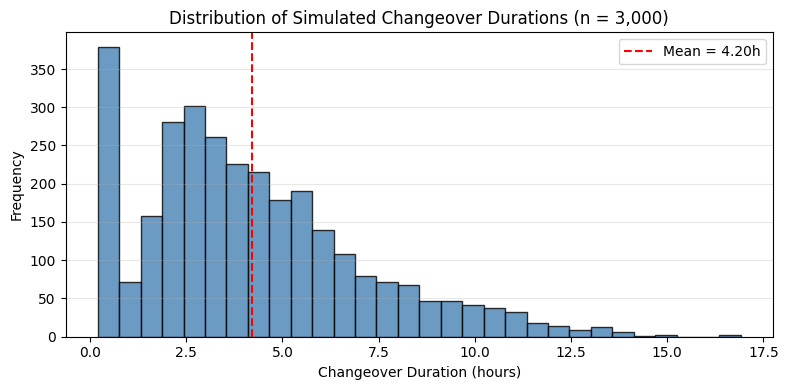

In [ ]:
# to plot distribution of simulated changeover durations
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(changeover_df["setup_duration_hours"], bins=30, color="steelblue", edgecolor="black", alpha=0.8)
ax.set_xlabel("Changeover Duration (hours)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Simulated Changeover Durations (n = 3,000)")
ax.axvline(changeover_df["setup_duration_hours"].mean(), color="red", linestyle="--",
           label=f"Mean = {changeover_df['setup_duration_hours'].mean():.2f}h")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

numerical_features = [
    "b_changed", "c_changed", "r_changed", "o_changed",
    "delta_b_len", "delta_openings", "n_changes",
    "crew_size", "operator_exp_years", "cycle_position",
]
categorical_features = ["mould_type", "shift"]
all_features = numerical_features + categorical_features

X = changeover_df[all_features].copy()
y = changeover_df["setup_duration_hours"].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features),
])

model_configs = {
    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]),
    "Ridge Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=1.0)),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=200, max_depth=12, min_samples_leaf=5,
            random_state=42, n_jobs=-1)),
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", GradientBoostingRegressor(
            n_estimators=300, max_depth=5, learning_rate=0.1,
            subsample=0.8, random_state=42)),
    ]),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []
trained_models = {}

print(f"\n{'Model':<25} {'CV MAE':>10} {'Test MAE':>10} {'Test RMSE':>10} {'Test R²':>10}")
print("-" * 70)

for name, pipeline in model_configs.items():
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=kf,
                                scoring="neg_mean_absolute_error", n_jobs=-1)
    cv_mae = -cv_scores.mean()

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name, "CV MAE (h)": round(cv_mae, 4),
        "Test MAE (h)": round(mae, 4), "Test RMSE (h)": round(rmse, 4),
        "Test R²": round(r2, 4),
    })
    trained_models[name] = pipeline
    print(f"{name:<25} {cv_mae:>10.4f} {mae:>10.4f} {rmse:>10.4f} {r2:>10.4f}")

results_df = pd.DataFrame(results)
best_name = results_df.loc[results_df["Test MAE (h)"].idxmin(), "Model"]
best_model = trained_models[best_name]
print(f"\n>>> Best model: {best_name}")
display(results_df)



Model                         CV MAE   Test MAE  Test RMSE    Test R²
----------------------------------------------------------------------
Linear Regression             0.5791     0.5693     0.7592     0.9290
Ridge Regression              0.5790     0.5693     0.7593     0.9290
Random Forest                 0.4428     0.4617     0.6298     0.9512
Gradient Boosting             0.4058     0.4237     0.5678     0.9603

>>> Best model: Gradient Boosting


,Model,CV MAE (h),Test MAE (h),Test RMSE (h),Test R²
0,Linear Regression,0.5791,0.5693,0.7592,0.9290
1,Ridge Regression,0.5790,0.5693,0.7593,0.9290
2,Random Forest,0.4428,0.4617,0.6298,0.9512
3,Gradient Boosting,0.4058,0.4237,0.5678,0.9603


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MAE: {mae:.2f} hours ({mae*60:.0f} minutes)")
print(f"Test R²:  {r2:.4f} ({r2*100:.1f}%)")

Test MAE: 0.42 hours (25 minutes)
Test R²:  0.9603 (96.0%)


In [ ]:
# three-way comparison: Baseline vs CP-SAT (Rules) vs CP-SAT (ML)

# needs trained ML model (best_model) and feature builder
# build ML-based arc costs
def ml_setup_cost(prev_cycle, curr_cycle):
    # use ML to predict changeover
    if prev_cycle is None:
        return 0
    prev_r = prev_cycle["recipe"]
    curr_r = curr_cycle["recipe"]

    features = {
        "b_changed": int(prev_r[0] != curr_r[0]),
        "c_changed": int(prev_r[1] != curr_r[1]),
        "r_changed": int(prev_r[2] != curr_r[2]),
        "o_changed": int(prev_r[3] != curr_r[3]),
        "delta_b_len": abs(prev_r[0] - curr_r[0]),
        "delta_openings": abs(prev_r[3] - curr_r[3]),
        "n_changes": sum([
            prev_r[0] != curr_r[0], prev_r[1] != curr_r[1],
            prev_r[2] != curr_r[2], prev_r[3] != curr_r[3]
        ]),
        "crew_size": 3,
        "operator_exp_years": 5.0,
        "cycle_position": 3,
        "mould_type": "square",
        "shift": "day",
    }

    df = pd.DataFrame([features])
    predicted_hours = best_model.predict(df)[0]
    # Scale to integer half-hours and clamp to minimum 0
    return max(0, int(predicted_hours * SCALE))


# Run CP-SAT with ML costs
def optimize_with_ml(cycles, mould_ids):
    """Same as optimize_sequences_cpsat but using ML predictions."""
    cycles_by_mould = defaultdict(list)
    for c in cycles:
        cycles_by_mould[c["mould_id"]].append(c)
    for mid in mould_ids:
        _ = cycles_by_mould[mid]

    model = cp_model.CpModel()
    mould_total_time = {}
    arcs_by_mould = {}

    for mid in mould_ids:
        mc = cycles_by_mould[mid]
        k = len(mc)
        if k == 0:
            mould_total_time[mid] = 0
            arcs_by_mould[mid] = []
            continue
        if k == 1:
            mould_total_time[mid] = CAST_T
            arcs_by_mould[mid] = []
            continue

        arcs = []
        setup_cost = {}
        for i in range(k + 1):
            for j in range(k + 1):
                if i == j:
                    continue
                lit = model.NewBoolVar(f"arc_{mid}_{i}_{j}")
                arcs.append((i, j, lit))
                if i == 0 or j == 0:
                    setup_cost[(i, j)] = 0
                else:
                    # ML prediction instead of rules
                    setup_cost[(i, j)] = ml_setup_cost(mc[i-1], mc[j-1])

        model.AddCircuit(arcs)
        setup_terms = []
        for (i, j, lit) in arcs:
            if i > 0 and j > 0 and setup_cost[(i, j)] > 0:
                setup_terms.append(setup_cost[(i, j)] * lit)

        total_setup = model.NewIntVar(0, 1_000_000, f"setup_{mid}")
        if setup_terms:
            model.Add(total_setup == sum(setup_terms))
        else:
            model.Add(total_setup == 0)

        total_time = model.NewIntVar(0, 1_000_000, f"time_{mid}")
        model.Add(total_time == k * CAST_T + total_setup)
        mould_total_time[mid] = total_time
        arcs_by_mould[mid] = arcs

    makespan = model.NewIntVar(0, 1_000_000, "makespan")
    for mid in mould_ids:
        tt = mould_total_time[mid]
        if isinstance(tt, int):
            model.Add(makespan >= tt)
        else:
            model.Add(makespan >= tt)
    model.Minimize(makespan)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 60
    status = solver.Solve(model)
    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        raise RuntimeError(f"CP-SAT ML failed: {solver.StatusName(status)}")

    sequences = {}
    times = {}
    for mid in mould_ids:
        mc = cycles_by_mould[mid]
        k = len(mc)
        if k == 0:
            sequences[mid] = []
            times[mid] = 0
            continue
        if k == 1:
            sequences[mid] = list(mc)
            times[mid] = CAST_T
            continue
        arcs = arcs_by_mould[mid]
        next_node = {}
        for (i, j, lit) in arcs:
            if solver.Value(lit) == 1:
                next_node[i] = j
        order = []
        cur = 0
        for _ in range(k):
            nxt = next_node.get(cur)
            if nxt is None or nxt == 0:
                break
            order.append(nxt - 1)
            cur = nxt
        sequences[mid] = [mc[i] for i in order]
        tt = mould_total_time[mid]
        times[mid] = solver.Value(tt) if not isinstance(tt, int) else tt

    return sequences, solver.Value(makespan), times


# Run ML-enhanced CP-SAT
ml_sequences, ml_makespan_scaled, ml_times = optimize_with_ml(cycles, all_mould_ids)

# Evaluate ML sequences using RULE-BASED costs (fair comparison)
ml_makespan_rules = 0
for mid in all_mould_ids:
    seq = ml_sequences.get(mid, [])
    t, prev = 0, None
    for cyc in seq:
        t += setup_time_scaled(prev, cyc["recipe"]) + CAST_T
        prev = cyc["recipe"]
    ml_makespan_rules = max(ml_makespan_rules, t)

# Baseline
bl_makespan = 0
for mid in all_mould_ids:
    bl_seq = [c for c in cycles if c["mould_id"] == mid]
    t, prev = 0, None
    for cyc in bl_seq:
        t += setup_time_scaled(prev, cyc["recipe"]) + CAST_T
        prev = cyc["recipe"]
    bl_makespan = max(bl_makespan, t)

bl_h = bl_makespan / SCALE
rules_h = makespan_scaled / SCALE  # from your existing CP-SAT run
ml_h = ml_makespan_rules / SCALE

print("=" * 60)
print("THREE-WAY COMPARISON")
print("=" * 60)
print(f"Baseline (heuristic order):    {bl_h:.1f}h")
print(f"CP-SAT (rule-based costs):     {rules_h:.1f}h  "
      f"({(bl_h-rules_h)/bl_h*100:.1f}% improvement)")
print(f"CP-SAT (ML-predicted costs):   {ml_h:.1f}h  "
      f"({(bl_h-ml_h)/bl_h*100:.1f}% improvement)")

THREE-WAY COMPARISON
Baseline (heuristic order):    43.5h
CP-SAT (rule-based costs):     40.0h  (8.0% improvement)
CP-SAT (ML-predicted costs):   40.0h  (8.0% improvement)


In [ ]:
# print ML sequence details
print("=" * 60)
print("CP-SAT (ML-PREDICTED) SEQUENCE DETAILS")
print("=" * 60)
for mid in all_mould_ids:
    seq = ml_sequences.get(mid, [])
    print(f"\n{mid}: {len(seq)} cycles")
    for step, cyc in enumerate(seq, start=1):
        pids = [p["panel_id"] for p in cyc["panels"]]
        print(f"  Step {step}: {pids}  recipe={cyc['recipe']}")

CP-SAT (ML-PREDICTED) SEQUENCE DETAILS

M1a: 4 cycles
  Step 1: ['1e/C02', '4b-m/C02', '1d/C03', '5a(a)/C04']  recipe=(2875, 1, 1, 1)
  Step 2: ['1a/C02', '4a/C02', '1a/C03']  recipe=(2875, 1, 1, 2)
  Step 3: ['3a-m(a)/C02', '3b/C02', '2b-m/C03', '4b(a)/C04']  recipe=(2625, 1, 1, 1)
  Step 4: ['3b-m/C03', '3b-m(a)/C03', '4b-m/C04']  recipe=(1665, 1, 1, 1)

M1b: 4 cycles
  Step 1: ['5a/C03', '5a(a)/C03']  recipe=(1740, 1, 1, 1)
  Step 2: ['1b/C02', '4a(a)/C02', '1b/C03']  recipe=(2875, 1, 1, 1)
  Step 3: ['2a/C02', '4b-m(a)/C02', '1e/C03']  recipe=(2865, 1, 1, 1)
  Step 4: ['3b(a)/C02', '3b-m/C02', '4b-m(a)/C04']  recipe=(2625, 1, 1, 1)

M1c: 4 cycles
  Step 1: ['2b/C02', '3a/C02', '2a/C03', '4a(a)/C04']  recipe=(2865, 1, 1, 1)
  Step 2: ['3b-m(a)/C02', '5a/C02', '1c/C04']  recipe=(2625, 1, 1, 2)
  Step 3: ['4a(a)/C03', '4b/C03', '5a/C04']  recipe=(1815, 1, 1, 1)
  Step 4: ['1c/C02', '4b/C02', '1c/C03']  recipe=(2875, 1, 1, 1)

M1d: 4 cycles
  Step 1: ['5a(a)/C02', '4a/C03', '1c-m/C04',

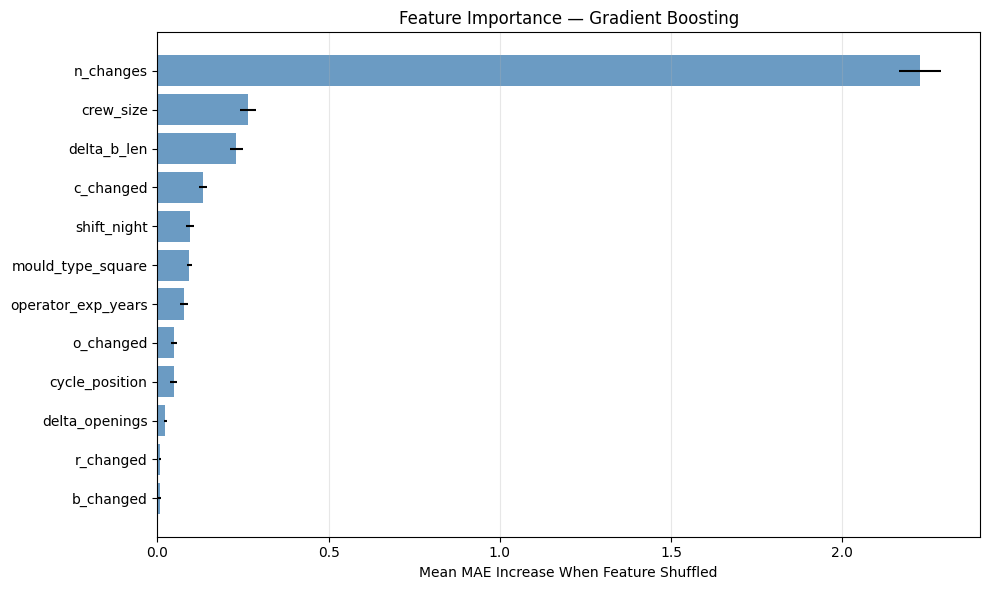

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# feature importance

perm_result = permutation_importance(
    best_model, X_test, y_test, n_repeats=20,
    random_state=42, n_jobs=-1, scoring="neg_mean_absolute_error"
)

ohe_cats = (best_model.named_steps["preprocessor"]
            .named_transformers_["cat"]
            .get_feature_names_out(categorical_features).tolist())
all_feature_names = numerical_features + ohe_cats

perm_imp = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std,
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_imp["Feature"], perm_imp["Importance"],
        xerr=perm_imp["Std"], color="steelblue", alpha=0.8)
ax.set_xlabel("Mean MAE Increase When Feature Shuffled")
ax.set_title(f"Feature Importance — {best_name}")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

from google.colab import files
files.download("feature_importance.png")


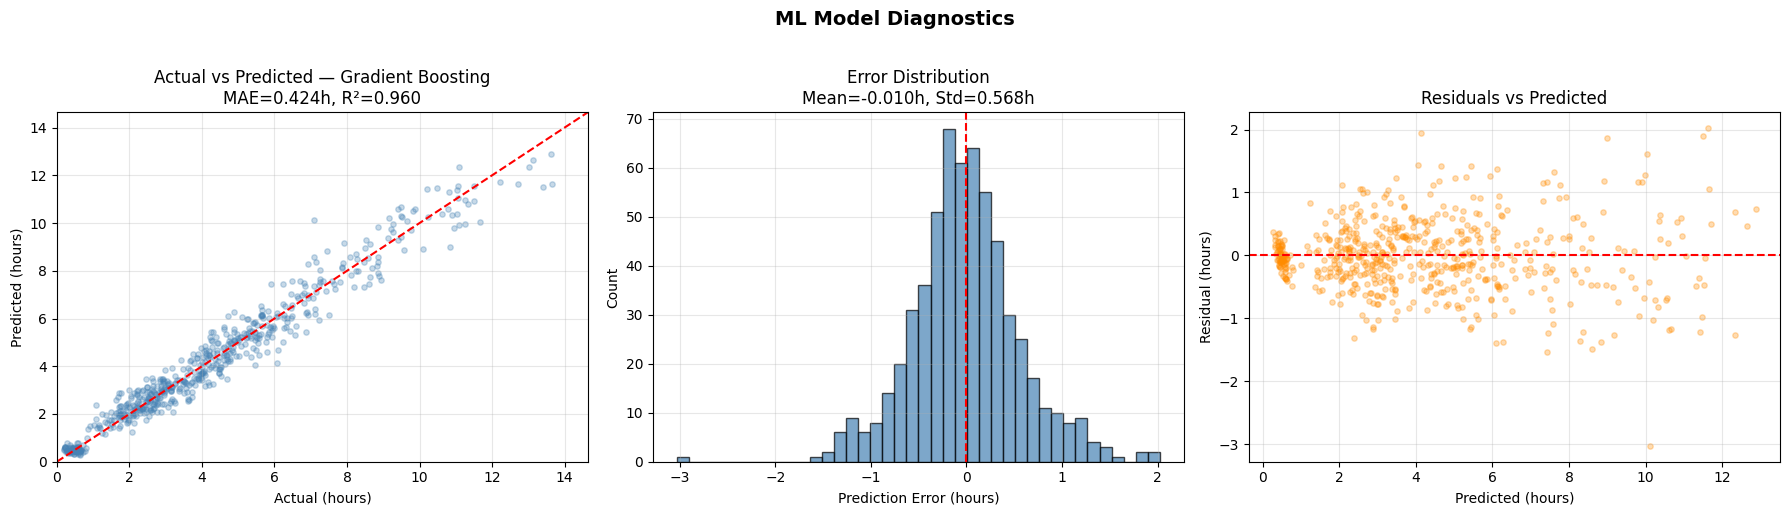


ML Model Comparison complete.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# diagnostic plots

y_pred_best = best_model.predict(X_test)
errors = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred_best, alpha=0.3, s=15, color="steelblue")
lims = [0, max(y_test.max(), y_pred_best.max()) + 1]
ax.plot(lims, lims, "r--", linewidth=1.5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual (hours)"); ax.set_ylabel("Predicted (hours)")
ax.set_title(f"Actual vs Predicted — {best_name}\n"
             f"MAE={mean_absolute_error(y_test, y_pred_best):.3f}h, "
             f"R²={r2_score(y_test, y_pred_best):.3f}")
ax.grid(alpha=0.3)

# Error distribution
ax = axes[1]
ax.hist(errors, bins=40, color="steelblue", edgecolor="black", alpha=0.7)
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Prediction Error (hours)"); ax.set_ylabel("Count")
ax.set_title(f"Error Distribution\nMean={errors.mean():.3f}h, Std={errors.std():.3f}h")
ax.grid(alpha=0.3)

# Residuals vs Predicted
ax = axes[2]
ax.scatter(y_pred_best, errors, alpha=0.3, s=15, color="darkorange")
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Predicted (hours)"); ax.set_ylabel("Residual (hours)")
ax.set_title("Residuals vs Predicted")
ax.grid(alpha=0.3)

plt.suptitle("ML Model Diagnostics", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("ml_diagnostics.png")
plt.show()

print("\nML Model Comparison complete.")

from google.colab import files
files.download("ml_diagnostics.png")


In [ ]:
# mould fleet config. scenaros
print("\n" + "=" * 65)
print("PART 2: MOULD FLEET CONFIGURATION SCENARIOS")
print("=" * 65)

mould_scenarios = {
    "Current fleet (4×M1 + M2 + M3)": [
        {"mould_id": "M1a", "mould_type": "square", "max_length": 3900},
        {"mould_id": "M1b", "mould_type": "square", "max_length": 3900},
        {"mould_id": "M1c", "mould_type": "square", "max_length": 3900},
        {"mould_id": "M1d", "mould_type": "square", "max_length": 3900},
        {"mould_id": "M2",  "mould_type": "square", "max_length": 3000},
        {"mould_id": "M3",  "mould_type": "cross",  "max_length": 2000, "quadrant_limit": 2000},
    ],
    "Square only (4×M1 + M2)": [
        {"mould_id": "M1a", "mould_type": "square", "max_length": 3900},
        {"mould_id": "M1b", "mould_type": "square", "max_length": 3900},
        {"mould_id": "M1c", "mould_type": "square", "max_length": 3900},
        {"mould_id": "M1d", "mould_type": "square", "max_length": 3900},
        {"mould_id": "M2",  "mould_type": "square", "max_length": 3000},
    ],
    "Minimal (2×M1 + M3)": [
        {"mould_id": "M1a", "mould_type": "square", "max_length": 3900},
        {"mould_id": "M1b", "mould_type": "square", "max_length": 3900},
        {"mould_id": "M3",  "mould_type": "cross",  "max_length": 2000, "quadrant_limit": 2000},
    ],
    "Large fleet (6×M1 + 2×cross)": [
        {"mould_id": "M1a", "mould_type": "square", "max_length": 3900},
        {"mould_id": "M1b", "mould_type": "square", "max_length": 3900},
        {"mould_id": "M1c", "mould_type": "square", "max_length": 3900},
        {"mould_id": "M1d", "mould_type": "square", "max_length": 3900},
        {"mould_id": "M1e", "mould_type": "square", "max_length": 3900},
        {"mould_id": "M1f", "mould_type": "square", "max_length": 3900},
        {"mould_id": "C1",  "mould_type": "cross",  "max_length": 2000, "quadrant_limit": 2000},
        {"mould_id": "C2",  "mould_type": "cross",  "max_length": 2000, "quadrant_limit": 2000},
    ],
}

mould_config_results = []

for scenario_name, mould_list in mould_scenarios.items():
    print(f"\n  Scenario: {scenario_name}")
    sc_moulds_records = mould_list
    sc_mould_ids = [m["mould_id"] for m in mould_list]

    # Check feasibility for cross-only scenarios
    has_square = any(m["mould_type"] == "square" for m in mould_list)
    if not has_square:
        qlimit = min(m.get("quadrant_limit", 9999) for m in mould_list
                     if m["mould_type"] == "cross")
        big_count = sum(1 for p in panels_records if not panel_fits_cross(p, qlimit))
        if big_count > 0:
            print(f"    SKIP: {big_count} panels too large for cross-only fleet")
            mould_config_results.append({
                "Scenario": scenario_name, "Moulds": len(mould_list),
                "Feasible": "No", "Cycles": "-",
                "Baseline (h)": "-", "CP-SAT (h)": "-",
            })
            continue

    try:
        t0 = time_module.time()

        # Batch
        sc_cycles = build_cycles_balanced(panels_records, sc_moulds_records)
        n_assigned = sum(len(c["panels"]) for c in sc_cycles)

        # Baseline makespan
        sc_baseline = defaultdict(list)
        for c in sc_cycles:
            sc_baseline[c["mould_id"]].append(c)
        ms_bl = 0
        for mid in sc_mould_ids:
            t, prev = 0, None
            for c in sc_baseline.get(mid, []):
                t += setup_time_scaled(prev, c["recipe"]) + CAST_T
                prev = c["recipe"]
            ms_bl = max(ms_bl, t)

        # CP-SAT optimised
        sc_seq, sc_ms, _ = optimize_sequences_cpsat(sc_cycles, mould_ids=sc_mould_ids)
        solve_time = time_module.time() - t0

        bl_h = round(ms_bl / SCALE, 1)
        opt_h = round(sc_ms / SCALE, 1)
        imp = round((ms_bl - sc_ms) / ms_bl * 100, 1) if ms_bl > 0 else 0

        mould_config_results.append({
            "Scenario": scenario_name,
            "Moulds": len(mould_list),
            "Feasible": "Yes",
            "Cycles": len(sc_cycles),
            "Panels Assigned": n_assigned,
            "Baseline (h)": bl_h,
            "CP-SAT (h)": opt_h,
            "Improvement (%)": imp,
            "Solve Time (s)": round(solve_time, 2),
        })
        print(f"    Cycles={len(sc_cycles)}, Baseline={bl_h}h, "
              f"CP-SAT={opt_h}h, Improvement={imp}%")

    except Exception as e:
        print(f"    ERROR: {e}")
        mould_config_results.append({
            "Scenario": scenario_name, "Moulds": len(mould_list),
            "Feasible": "Error", "Cycles": "-",
            "Baseline (h)": "-", "CP-SAT (h)": "-",
        })

mould_config_df = pd.DataFrame(mould_config_results)
display(mould_config_df)



PART 2: MOULD FLEET CONFIGURATION SCENARIOS

  Scenario: Current fleet (4×M1 + M2 + M3)
    Cycles=23, Baseline=43.5h, CP-SAT=40.0h, Improvement=8.0%

  Scenario: Square only (4×M1 + M2)
    Cycles=25, Baseline=50.0h, CP-SAT=48.0h, Improvement=4.0%

  Scenario: Minimal (2×M1 + M3)
    Cycles=21, Baseline=69.0h, CP-SAT=63.5h, Improvement=8.0%

  Scenario: Large fleet (6×M1 + 2×cross)
    Cycles=23, Baseline=36.0h, CP-SAT=30.5h, Improvement=15.3%


,Scenario,Moulds,Feasible,Cycles,Panels Assigned,Baseline (h),CP-SAT (h),Improvement (%),Solve Time (s)
0,Current fleet (4×M1 + M2 + M3),6,Yes,23,75,43.5,40.0,8.0,0.14
1,Square only (4×M1 + M2),5,Yes,25,75,50.0,48.0,4.0,0.15
2,Minimal (2×M1 + M3),3,Yes,21,75,69.0,63.5,8.0,0.16
3,Large fleet (6×M1 + 2×cross),8,Yes,23,75,36.0,30.5,15.3,0.13


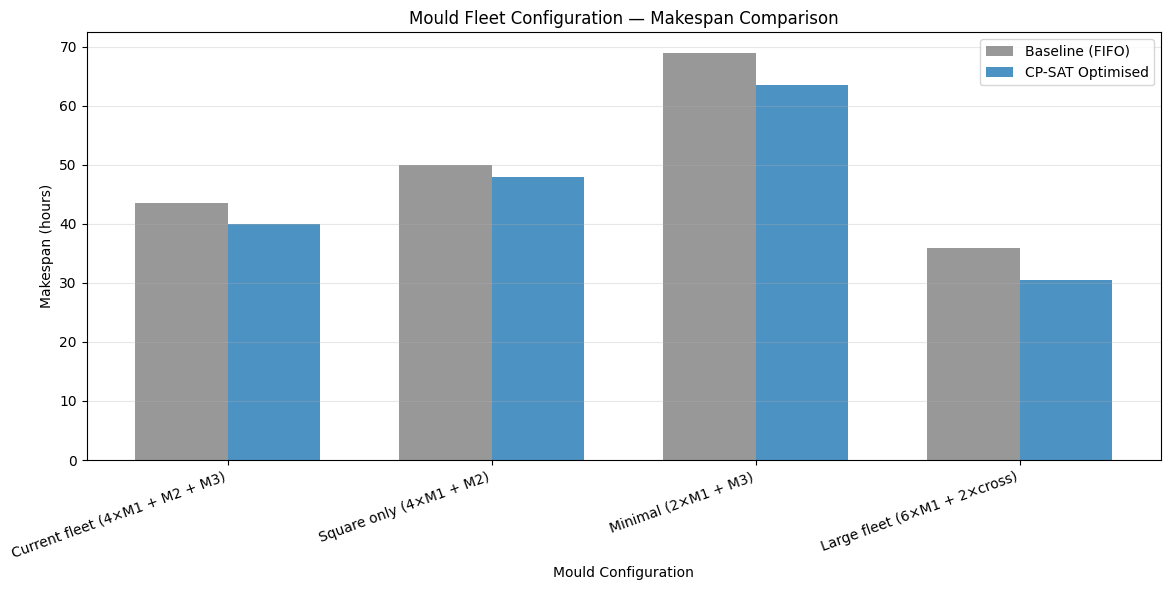


Mould configuration analysis complete.


In [ ]:
# plot
valid_mc = mould_config_df[mould_config_df["Feasible"] == "Yes"].copy()
if not valid_mc.empty:
    for col in ["Baseline (h)", "CP-SAT (h)"]:
        valid_mc[col] = valid_mc[col].astype(float)

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(valid_mc))
    width = 0.35

    ax.bar(x - width/2, valid_mc["Baseline (h)"].values, width,
           label="Baseline (FIFO)", color="tab:gray", alpha=0.8)
    ax.bar(x + width/2, valid_mc["CP-SAT (h)"].values, width,
           label="CP-SAT Optimised", color="tab:blue", alpha=0.8)

    ax.set_xlabel("Mould Configuration")
    ax.set_ylabel("Makespan (hours)")
    ax.set_title("Mould Fleet Configuration — Makespan Comparison")
    ax.set_xticks(x)
    ax.set_xticklabels(valid_mc["Scenario"].values, rotation=20, ha="right")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\nMould configuration analysis complete.")


PBU COMPLETION AND CO-LOCATION ANALYSIS

Total PBUs: 25
Each PBU needs 3 panels (C02, C03, C04) before assembly

────────────────────────────────────────────────────────────
PBU COMPLETION TIME (Optimised Schedule)
────────────────────────────────────────────────────────────
PBU        C02 done   C03 done   C04 done   PBU ready  Wait (h)   Moulds used
────────────────────────────────────────────────────────────────────────────────
1a         36.5       36.5       15.5       36.5       21.0       ['M1a', 'M2']
1b         34.5       34.5       6.0        34.5       28.5       ['M1b', 'M2']
1c         38.5       38.5       27.0       38.5       11.5       ['M1c']
1c-m       27.0       27.0       6.0        27.0       21.0       ['M1d']
1d         15.5       6.0        6.0        15.5       9.5        ['M1a', 'M1d', 'M2']
1e         6.0        15.5       27.0       27.0       21.0       ['M1a', 'M1b', 'M2']
2a         15.5       6.0        40.0       40.0       34.0       ['M1b', 'M1c', 'M

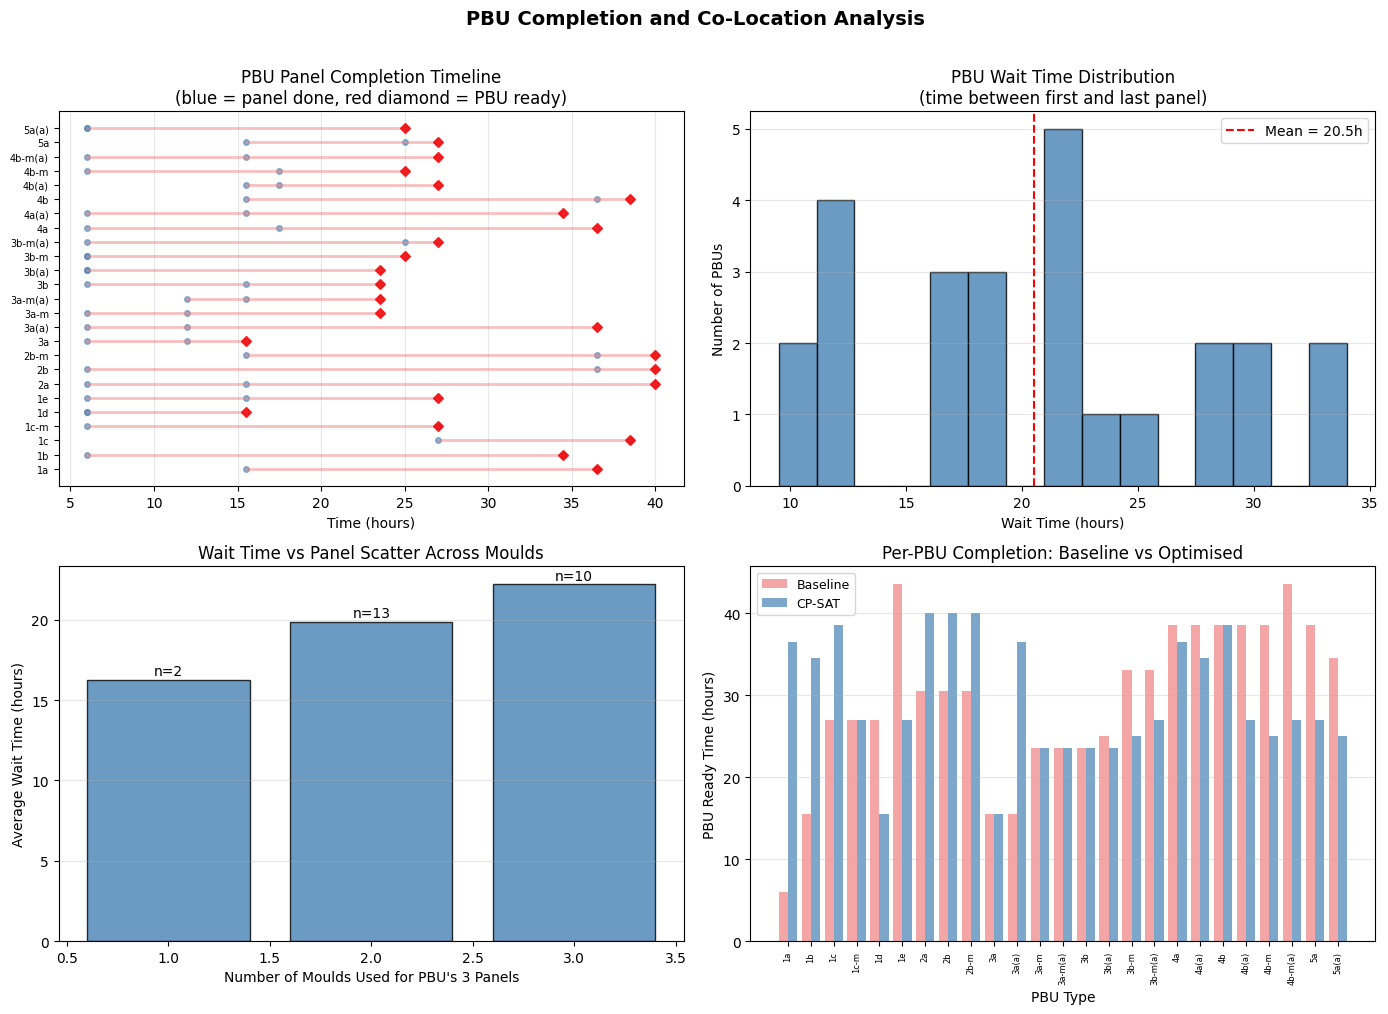

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon

# PBU COMPLETION AND CO-LOCATION ANALYSIS

print("=" * 60)
print("PBU COMPLETION AND CO-LOCATION ANALYSIS")
print("=" * 60)

# Build optimised schedule timeline
opt_schedule = {}  # panel_id -> end_time_h
for mid in all_mould_ids:
    seq = sequences_by_mould.get(mid, [])
    t = 0
    prev = None
    for cyc in seq:
        setup = setup_time_scaled(prev, cyc["recipe"]) / SCALE
        cast = CAST_TIME_H
        t += setup + cast
        # All panels in this cycle finish at time t
        for p in cyc["panels"]:
            opt_schedule[p["panel_id"]] = {
                "end_h": t,
                "mould": mid,
                "cycle_recipe": cyc["recipe"],
            }
        prev = cyc["recipe"]

# Also build baseline schedule
bl_schedule = {}
for mid in all_mould_ids:
    bl_seq = [c for c in cycles if c["mould_id"] == mid]
    t = 0
    prev = None
    for cyc in bl_seq:
        setup = setup_time_scaled(prev, cyc["recipe"]) / SCALE
        cast = CAST_TIME_H
        t += setup + cast
        for p in cyc["panels"]:
            bl_schedule[p["panel_id"]] = {
                "end_h": t,
                "mould": mid,
            }
        prev = cyc["recipe"]

# Get all PBU IDs
pbu_ids_list = sorted(set(p["panel_id"].split("/")[0] for p in panels_records))

print(f"\nTotal PBUs: {len(pbu_ids_list)}")
print(f"Each PBU needs 3 panels (C02, C03, C04) before assembly\n")

# ── PBU Completion Analysis ──
print("─" * 60)
print("PBU COMPLETION TIME (Optimised Schedule)")
print("─" * 60)
print(f"{'PBU':<10} {'C02 done':<10} {'C03 done':<10} {'C04 done':<10} "
      f"{'PBU ready':<10} {'Wait (h)':<10} {'Moulds used'}")
print("─" * 80)

pbu_data = []
for pbu in pbu_ids_list:
    panels_info = {}
    moulds_used = set()
    for code in ["C02", "C03", "C04"]:
        pid = f"{pbu}/{code}"
        if pid in opt_schedule:
            panels_info[code] = opt_schedule[pid]["end_h"]
            moulds_used.add(opt_schedule[pid]["mould"])

    if len(panels_info) == 3:
        first_done = min(panels_info.values())
        last_done = max(panels_info.values())
        wait = last_done - first_done

        pbu_data.append({
            "PBU": pbu,
            "C02_done": panels_info["C02"],
            "C03_done": panels_info["C03"],
            "C04_done": panels_info["C04"],
            "PBU_ready": last_done,
            "Wait_h": round(wait, 1),
            "Moulds_used": len(moulds_used),
            "Mould_list": sorted(moulds_used),
            "Co_located": len(moulds_used) == 1,
        })

        print(f"{pbu:<10} {panels_info['C02'] :<10.1f} {panels_info['C03'] :<10.1f} "
              f"{panels_info['C04'] :<10.1f} {last_done:<10.1f} {wait:<10.1f} "
              f"{sorted(moulds_used)}")

pbu_df = pd.DataFrame(pbu_data)

# Summary stats
print(f"\n{'─'*60}")
print(f"SUMMARY")
print(f"{'─'*60}")
avg_wait = pbu_df["Wait_h"].mean()
max_wait = pbu_df["Wait_h"].max()
min_wait = pbu_df["Wait_h"].min()
zero_wait = (pbu_df["Wait_h"] == 0).sum()

print(f"Average wait time:  {avg_wait:.1f} hours")
print(f"Maximum wait time:  {max_wait:.1f} hours")
print(f"Minimum wait time:  {min_wait:.1f} hours")
print(f"PBUs with zero wait (all panels same cycle): {zero_wait}/{len(pbu_df)}")

# ── Co-location Analysis ──
print(f"\n{'─'*60}")
print(f"CO-LOCATION ANALYSIS")
print(f"{'─'*60}")
for n in sorted(pbu_df["Moulds_used"].unique()):
    count = (pbu_df["Moulds_used"] == n).sum()
    avg_w = pbu_df[pbu_df["Moulds_used"] == n]["Wait_h"].mean()
    print(f"Panels on {n} mould(s): {count} PBUs, avg wait = {avg_w:.1f}h")

# ── Baseline vs Optimised PBU completion ──
print(f"\n{'─'*60}")
print(f"BASELINE vs OPTIMISED PBU COMPLETION")
print(f"{'─'*60}")

bl_pbu_data = []
for pbu in pbu_ids_list:
    panels_info = {}
    for code in ["C02", "C03", "C04"]:
        pid = f"{pbu}/{code}"
        if pid in bl_schedule:
            panels_info[code] = bl_schedule[pid]["end_h"]
    if len(panels_info) == 3:
        bl_pbu_data.append({
            "PBU": pbu,
            "PBU_ready": max(panels_info.values()),
            "Wait_h": max(panels_info.values()) - min(panels_info.values()),
        })

bl_pbu_df = pd.DataFrame(bl_pbu_data)

print(f"                    Baseline    Optimised")
print(f"Avg wait time:      {bl_pbu_df['Wait_h'].mean():.1f}h        {pbu_df['Wait_h'].mean():.1f}h")
print(f"Max wait time:      {bl_pbu_df['Wait_h'].max():.1f}h        {pbu_df['Wait_h'].max():.1f}h")
print(f"Avg PBU ready time: {bl_pbu_df['PBU_ready'].mean():.1f}h       {pbu_df['PBU_ready'].mean():.1f}h")
print(f"Last PBU ready:     {bl_pbu_df['PBU_ready'].max():.1f}h       {pbu_df['PBU_ready'].max():.1f}h")

# ── Charts ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left: PBU completion timeline
ax = axes[0][0]
for i, row in pbu_df.iterrows():
    y = i
    ax.plot([row["C02_done"], row["C03_done"], row["C04_done"]], [y, y, y],
            "o", markersize=4, color="steelblue", alpha=0.6)
    ax.plot([min(row["C02_done"], row["C03_done"], row["C04_done"]),
             row["PBU_ready"]], [y, y], "-", color="lightcoral", alpha=0.5, linewidth=2)
    ax.plot(row["PBU_ready"], y, "D", markersize=5, color="red", alpha=0.8)
ax.set_yticks(range(len(pbu_df)))
ax.set_yticklabels(pbu_df["PBU"], fontsize=7)
ax.set_xlabel("Time (hours)")
ax.set_title("PBU Panel Completion Timeline\n(blue = panel done, red diamond = PBU ready)")
ax.grid(axis="x", alpha=0.3)

# Top right: Wait time distribution
ax2 = axes[0][1]
ax2.hist(pbu_df["Wait_h"], bins=15, color="steelblue", edgecolor="black", alpha=0.8)
ax2.axvline(avg_wait, color="red", linestyle="--", label=f"Mean = {avg_wait:.1f}h")
ax2.set_xlabel("Wait Time (hours)")
ax2.set_ylabel("Number of PBUs")
ax2.set_title("PBU Wait Time Distribution\n(time between first and last panel)")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

# Bottom left: Wait time by number of moulds used
ax3 = axes[1][0]
mould_groups = pbu_df.groupby("Moulds_used")["Wait_h"].agg(["mean", "std", "count"])
ax3.bar(mould_groups.index, mould_groups["mean"], color="steelblue", edgecolor="black", alpha=0.8)
for idx, row in mould_groups.iterrows():
    ax3.text(idx, row["mean"] + 0.3, f"n={int(row['count'])}", ha="center", fontsize=10)
ax3.set_xlabel("Number of Moulds Used for PBU's 3 Panels")
ax3.set_ylabel("Average Wait Time (hours)")
ax3.set_title("Wait Time vs Panel Scatter Across Moulds")
ax3.grid(axis="y", alpha=0.3)

# Bottom right: Baseline vs Optimised PBU ready times
ax4 = axes[1][1]
x = range(len(pbu_ids_list))
ax4.bar([i - 0.2 for i in x], bl_pbu_df["PBU_ready"], 0.4,
        label="Baseline", color="lightcoral", alpha=0.7)
ax4.bar([i + 0.2 for i in x], pbu_df["PBU_ready"], 0.4,
        label="CP-SAT", color="steelblue", alpha=0.7)
ax4.set_xticks(x)
ax4.set_xticklabels(pbu_ids_list, rotation=90, fontsize=6)
ax4.set_xlabel("PBU Type")
ax4.set_ylabel("PBU Ready Time (hours)")
ax4.set_title("Per-PBU Completion: Baseline vs Optimised")
ax4.legend(fontsize=9)
ax4.grid(axis="y", alpha=0.3)
ax4.axhline(0, color='grey', linestyle='--', linewidth=0.7)

plt.suptitle("PBU Completion and Co-Location Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("pbu_completion")
plt.show()
